In [14]:
import pandas as pd

df = pd.read_csv("../data/student_performance_prediction.csv")

df.head()

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
0,S00001,12.5,NaN,75.0,Yes,Master,Yes
1,S00002,9.3,95.3,60.6,No,High School,No
2,S00003,13.2,NaN,64.0,No,Associate,No
3,S00004,17.6,76.8,62.4,Yes,Bachelor,No
4,S00005,8.8,89.3,72.7,No,Master,No


In [15]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 7 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Student ID                                   40000 non-null  str    
 1   Study Hours per Week                         38005 non-null  float64
 2   Attendance Rate                              38008 non-null  float64
 3   Previous Grades                              38006 non-null  float64
 4   Participation in Extracurricular Activities  38000 non-null  str    
 5   Parent Education Level                       38000 non-null  str    
 6   Passed                                       38000 non-null  str    
dtypes: float64(3), str(4)
memory usage: 2.9 MB


Student ID                                        0
Study Hours per Week                           1995
Attendance Rate                                1992
Previous Grades                                1994
Participation in Extracurricular Activities    2000
Parent Education Level                         2000
Passed                                         2000
dtype: int64

===== DATASET SHAPE =====
(40000, 7)

===== FIRST 5 ROWS =====
  Student ID  Study Hours per Week  Attendance Rate  Previous Grades  \
0     S00001                  12.5              NaN             75.0   
1     S00002                   9.3             95.3             60.6   
2     S00003                  13.2              NaN             64.0   
3     S00004                  17.6             76.8             62.4   
4     S00005                   8.8             89.3             72.7   

  Participation in Extracurricular Activities Parent Education Level Passed  
0                                         Yes                 Master    Yes  
1                                          No            High School     No  
2                                          No              Associate     No  
3                                         Yes               Bachelor     No  
4                                          No                 Master     No  

===== LAST 5 ROWS =====
      Stude

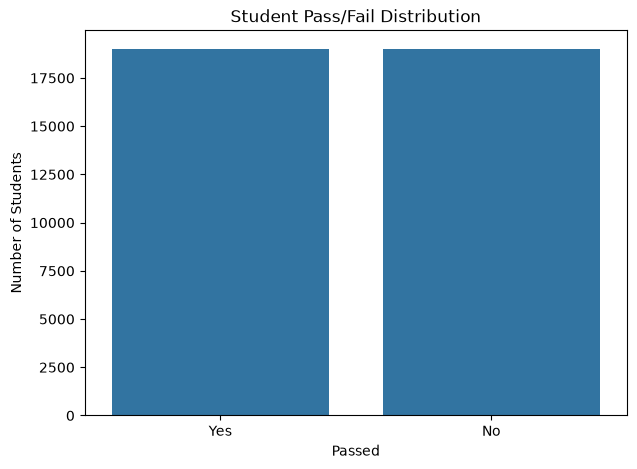

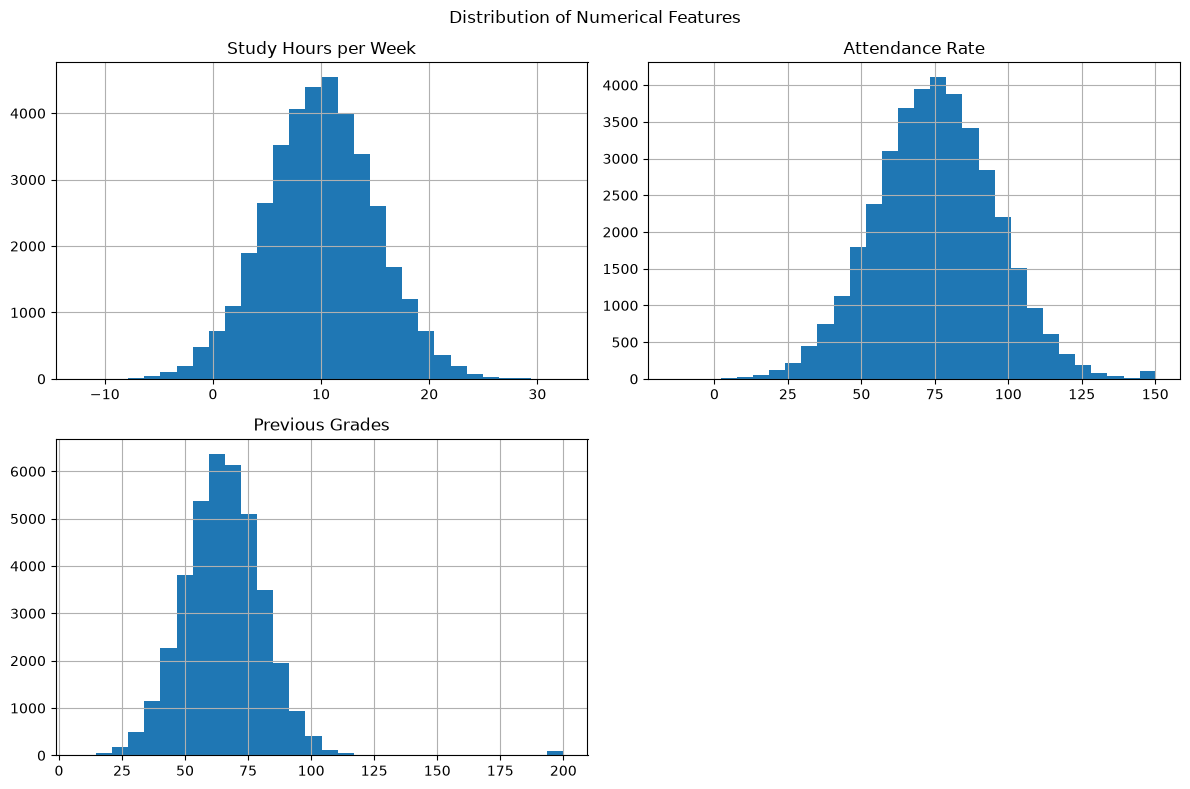

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Load the dataset
# ==========================================

df = pd.read_csv("../data/student_performance_prediction.csv")


# ==========================================
# 2. Basic information
# ==========================================

print("===== DATASET SHAPE =====")
print(df.shape)

print("\n===== FIRST 5 ROWS =====")
print(df.head())

print("\n===== LAST 5 ROWS =====")
print(df.tail())

print("\n===== DATASET INFORMATION =====")
df.info()


# ==========================================
# 3. Statistical summary
# ==========================================

print("\n===== STATISTICAL SUMMARY =====")
print(df.describe())


# ==========================================
# 4. Missing values
# ==========================================

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

print("\n===== MISSING VALUE PERCENTAGE =====")
print((df.isnull().sum() / len(df) * 100).round(2))


# ==========================================
# 5. Duplicate rows
# ==========================================

print("\n===== DUPLICATE ROWS =====")
print(df.duplicated().sum())


# ==========================================
# 6. Unique values in categorical columns
# ==========================================

categorical_columns = [
    "Participation in Extracurricular Activities",
    "Parent Education Level",
    "Passed"
]

print("\n===== UNIQUE VALUES =====")

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts(dropna=False))


# ==========================================
# 7. Numerical column distributions
# ==========================================

numerical_columns = [
    "Study Hours per Week",
    "Attendance Rate",
    "Previous Grades"
]

print("\n===== NUMERICAL COLUMN RANGES =====")

for column in numerical_columns:
    print(f"\n{column}")
    print("Minimum :", df[column].min())
    print("Maximum :", df[column].max())
    print("Mean    :", round(df[column].mean(), 2))
    print("Median  :", round(df[column].median(), 2))


# ==========================================
# 8. Target distribution
# ==========================================

print("\n===== TARGET DISTRIBUTION =====")
print(df["Passed"].value_counts(dropna=False))


# ==========================================
# 9. Visualize target distribution
# ==========================================

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Passed")

plt.title("Student Pass/Fail Distribution")
plt.xlabel("Passed")
plt.ylabel("Number of Students")

plt.show()


# ==========================================
# 10. Visualize numerical features
# ==========================================

df[numerical_columns].hist(
    figsize=(12, 8),
    bins=30
)

plt.suptitle("Distribution of Numerical Features")

plt.tight_layout()
plt.show()

In [17]:
# ==========================================
# STEP 2: FIND INVALID VALUES
# ==========================================

# Define the valid ranges for our numerical features
valid_ranges = {
    "Study Hours per Week": (0, None),
    "Attendance Rate": (0, 100),
    "Previous Grades": (0, 100)
}

print("===== INVALID VALUES =====")

for column, (minimum, maximum) in valid_ranges.items():

    if minimum is not None:
        invalid_min = df[column] < minimum
    else:
        invalid_min = False

    if maximum is not None:
        invalid_max = df[column] > maximum
    else:
        invalid_max = False

    invalid = invalid_min | invalid_max

    print(f"\n{column}")
    print("Invalid values:", invalid.sum())

    if invalid.sum() > 0:
        print("Examples:")
        print(df.loc[invalid, [column]].head(10))


# ==========================================
# Check all rows containing invalid values
# ==========================================

invalid_study = (
    (df["Study Hours per Week"] < 0)
)

invalid_attendance = (
    (df["Attendance Rate"] < 0) |
    (df["Attendance Rate"] > 100)
)

invalid_grades = (
    (df["Previous Grades"] < 0) |
    (df["Previous Grades"] > 100)
)

invalid_rows = (
    invalid_study |
    invalid_attendance |
    invalid_grades
)

print("\n===== TOTAL ROWS WITH INVALID NUMERICAL DATA =====")
print(invalid_rows.sum())

print("\n===== SAMPLE INVALID ROWS =====")
print(
    df.loc[
        invalid_rows,
        [
            "Student ID",
            "Study Hours per Week",
            "Attendance Rate",
            "Previous Grades",
            "Passed"
        ]
    ].head(20)
)

===== INVALID VALUES =====

Study Hours per Week
Invalid values: 941
Examples:
     Study Hours per Week
74                   -3.1
236                  -0.1
262                  -6.2
366                  -1.0
382                  -0.6
431                  -0.2
442                  -0.3
452                  -1.0
471                  -1.5
544                  -2.4

Attendance Rate
Invalid values: 4142
Examples:
    Attendance Rate
8             100.1
11            115.5
20            110.3
26            112.4
30            111.0
42            125.8
49            118.9
50            127.4
56            113.8
69            104.6

Previous Grades
Invalid values: 481
Examples:
     Previous Grades
97             200.0
185            102.0
318            200.0
377            200.0
585            200.0
637            200.0
729            104.0
739            101.5
752            200.0
811            102.9

===== TOTAL ROWS WITH INVALID NUMERICAL DATA =====
5404

===== SAMPLE INVALID ROWS =====

In [18]:
# ==========================================
# STEP 3: DATA CLEANING
# ==========================================

import pandas as pd
import numpy as np

# Make a copy so that we keep the original
# dataframe unchanged
clean_df = df.copy()


# ==========================================
# 1. Remove rows where target is missing
# ==========================================

clean_df = clean_df.dropna(subset=["Passed"])


# ==========================================
# 2. Convert invalid numerical values to NaN
# ==========================================

# Study hours cannot be negative
clean_df.loc[
    clean_df["Study Hours per Week"] < 0,
    "Study Hours per Week"
] = np.nan


# Attendance must be between 0 and 100
clean_df.loc[
    (clean_df["Attendance Rate"] < 0) |
    (clean_df["Attendance Rate"] > 100),
    "Attendance Rate"
] = np.nan


# Previous grades must be between 0 and 100
clean_df.loc[
    (clean_df["Previous Grades"] < 0) |
    (clean_df["Previous Grades"] > 100),
    "Previous Grades"
] = np.nan


# ==========================================
# 3. Fill missing numerical values
#    using the median
# ==========================================

numerical_columns = [
    "Study Hours per Week",
    "Attendance Rate",
    "Previous Grades"
]

for column in numerical_columns:
    clean_df[column] = clean_df[column].fillna(
        clean_df[column].median()
    )


# ==========================================
# 4. Fill missing categorical values
#    using the mode
# ==========================================

categorical_columns = [
    "Participation in Extracurricular Activities",
    "Parent Education Level"
]

for column in categorical_columns:
    clean_df[column] = clean_df[column].fillna(
        clean_df[column].mode()[0]
    )


# ==========================================
# 5. Remove Student ID
# ==========================================

clean_df = clean_df.drop(columns=["Student ID"])


# ==========================================
# 6. Check the cleaned dataset
# ==========================================

print("===== CLEANED DATASET SHAPE =====")
print(clean_df.shape)


print("\n===== MISSING VALUES AFTER CLEANING =====")
print(clean_df.isnull().sum())


print("\n===== DATA TYPES =====")
print(clean_df.dtypes)


print("\n===== FIRST 10 CLEANED ROWS =====")
print(clean_df.head(10))


# ==========================================
# 7. Verify numerical ranges
# ==========================================

print("\n===== CLEANED NUMERICAL RANGES =====")

for column in numerical_columns:
    print(f"\n{column}")
    print("Minimum :", clean_df[column].min())
    print("Maximum :", clean_df[column].max())
    print("Median  :", clean_df[column].median())


# ==========================================
# 8. Verify target distribution
# ==========================================

print("\n===== TARGET DISTRIBUTION =====")
print(clean_df["Passed"].value_counts())


# ==========================================
# 9. Save cleaned dataset
# ==========================================

clean_df.to_csv(
    "../data/student_performance_cleaned.csv",
    index=False
)

print("\nCleaned dataset saved successfully!")

===== CLEANED DATASET SHAPE =====
(38000, 6)

===== MISSING VALUES AFTER CLEANING =====
Study Hours per Week                           0
Attendance Rate                                0
Previous Grades                                0
Participation in Extracurricular Activities    0
Parent Education Level                         0
Passed                                         0
dtype: int64

===== DATA TYPES =====
Study Hours per Week                           float64
Attendance Rate                                float64
Previous Grades                                float64
Participation in Extracurricular Activities        str
Parent Education Level                             str
Passed                                             str
dtype: object

===== FIRST 10 CLEANED ROWS =====
    Study Hours per Week  Attendance Rate  Previous Grades  \
0                   12.5             72.4             75.0   
1                    9.3             95.3             60.6   
2               

===== PASS / FAIL DISTRIBUTION =====
Passed
Yes    19011
No     18989
Name: count, dtype: int64

Percentage:
Passed
Yes    50.03
No     49.97
Name: proportion, dtype: float64


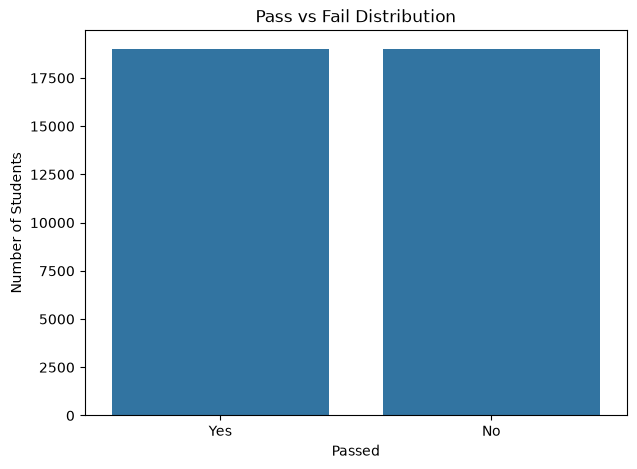


===== STUDY HOURS VS PASSING =====
             mean  median  min   max
Passed                              
No      10.307467    10.1  0.0  32.4
Yes     10.200337    10.1  0.0  29.6


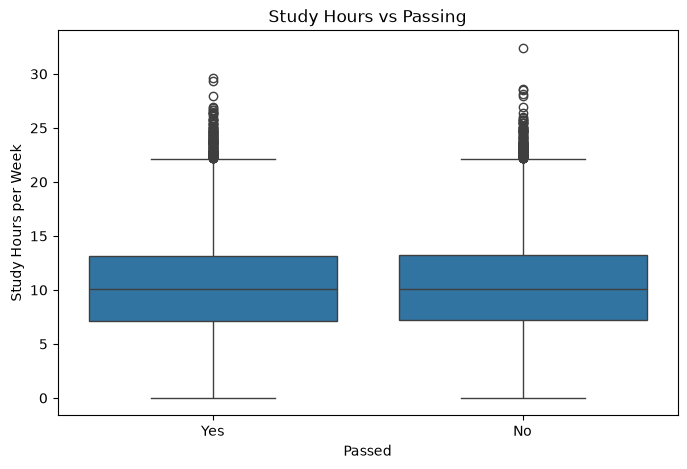


===== ATTENDANCE VS PASSING =====
             mean  median  min    max
Passed                               
No      71.142177    72.4  3.1  100.0
Yes     71.209800    72.4  0.5  100.0


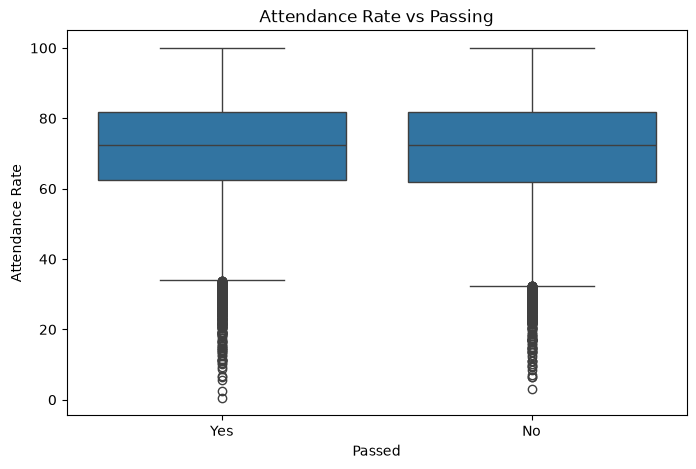


===== PREVIOUS GRADES VS PASSING =====
             mean  median  min    max
Passed                               
No      64.676781    64.9  8.3  100.0
Yes     64.697023    64.9  9.4   99.9


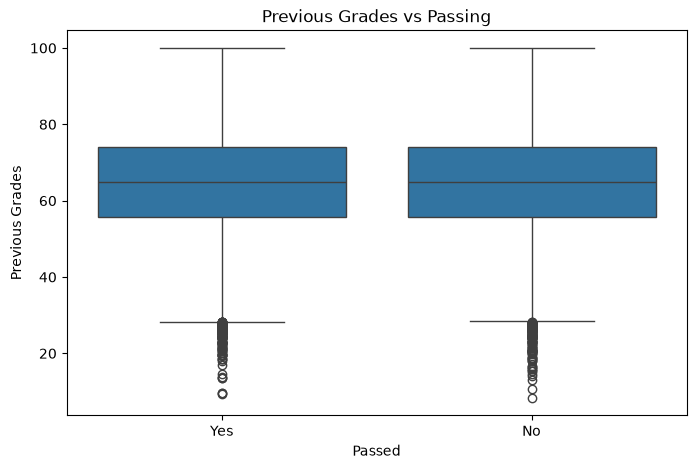


===== EXTRACURRICULAR ACTIVITIES VS PASSING =====
Passed                                         No   Yes
Participation in Extracurricular Activities            
No                                           9980  9988
Yes                                          9009  9023

Percentage within each extracurricular group:
Passed                                         No   Yes
Participation in Extracurricular Activities            
No                                           50.0  50.0
Yes                                          50.0  50.0


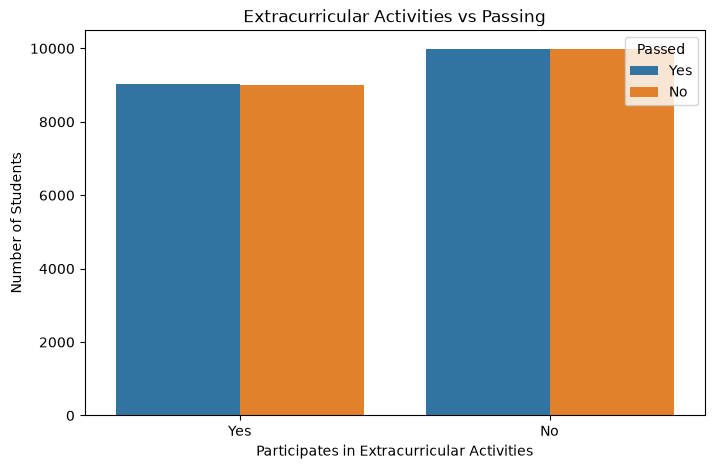


===== PARENT EDUCATION VS PASSING =====
Passed                    No   Yes
Parent Education Level            
Associate               3676  3565
Bachelor                4575  4613
Doctorate               3567  3683
High School             3621  3643
Master                  3550  3507

Percentage within each parent education group:
Passed                    No   Yes
Parent Education Level            
Associate               50.8  49.2
Bachelor                49.8  50.2
Doctorate               49.2  50.8
High School             49.8  50.2
Master                  50.3  49.7


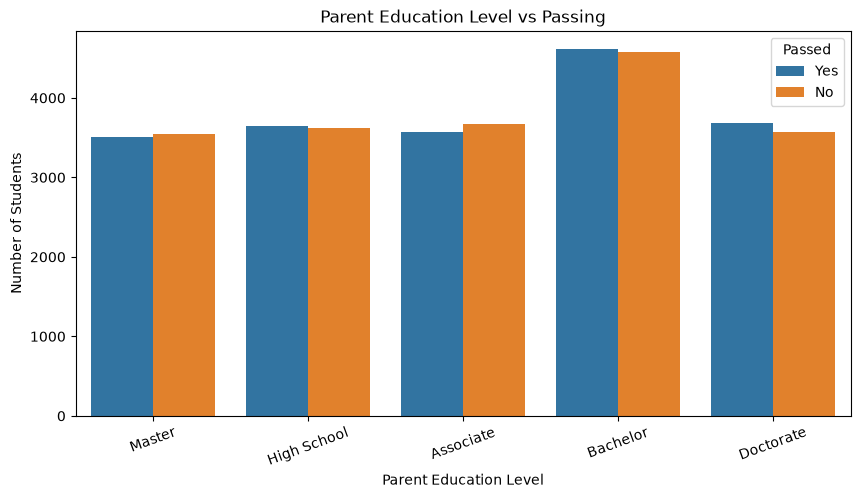


===== CORRELATION MATRIX =====
                      Study Hours per Week  Attendance Rate  Previous Grades
Study Hours per Week              1.000000         0.001495         0.003046
Attendance Rate                   0.001495         1.000000        -0.002882
Previous Grades                   0.003046        -0.002882         1.000000


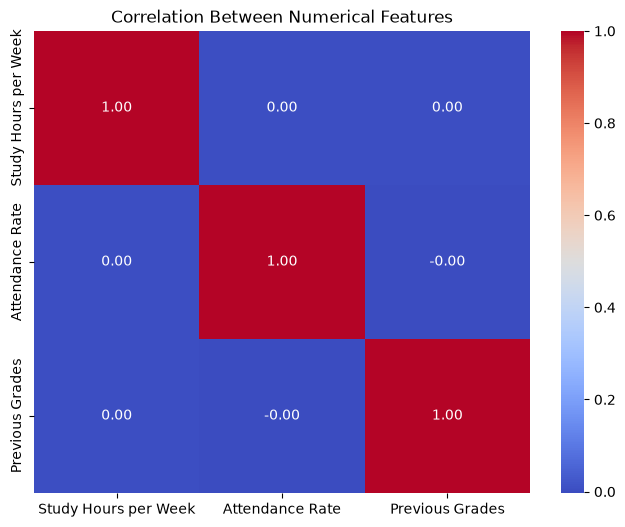

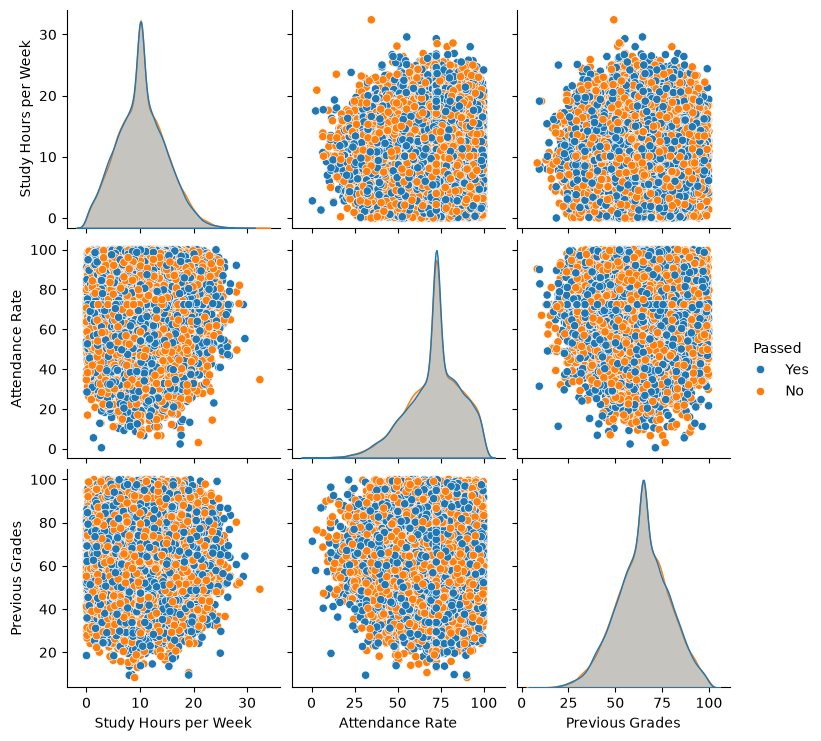

In [19]:
# ==========================================
# STEP 4: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Use the cleaned dataset
df = clean_df.copy()


# ==========================================
# 1. PASS / FAIL DISTRIBUTION
# ==========================================

print("===== PASS / FAIL DISTRIBUTION =====")

print(df["Passed"].value_counts())

print("\nPercentage:")
print(
    (df["Passed"].value_counts(normalize=True) * 100)
    .round(2)
)


plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Passed"
)

plt.title("Pass vs Fail Distribution")
plt.xlabel("Passed")
plt.ylabel("Number of Students")

plt.show()


# ==========================================
# 2. STUDY HOURS VS PASSING
# ==========================================

print("\n===== STUDY HOURS VS PASSING =====")

print(
    df.groupby("Passed")["Study Hours per Week"]
    .agg(["mean", "median", "min", "max"])
)


plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Passed",
    y="Study Hours per Week"
)

plt.title("Study Hours vs Passing")
plt.xlabel("Passed")
plt.ylabel("Study Hours per Week")

plt.show()


# ==========================================
# 3. ATTENDANCE VS PASSING
# ==========================================

print("\n===== ATTENDANCE VS PASSING =====")

print(
    df.groupby("Passed")["Attendance Rate"]
    .agg(["mean", "median", "min", "max"])
)


plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Passed",
    y="Attendance Rate"
)

plt.title("Attendance Rate vs Passing")
plt.xlabel("Passed")
plt.ylabel("Attendance Rate")

plt.show()


# ==========================================
# 4. PREVIOUS GRADES VS PASSING
# ==========================================

print("\n===== PREVIOUS GRADES VS PASSING =====")

print(
    df.groupby("Passed")["Previous Grades"]
    .agg(["mean", "median", "min", "max"])
)


plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Passed",
    y="Previous Grades"
)

plt.title("Previous Grades vs Passing")
plt.xlabel("Passed")
plt.ylabel("Previous Grades")

plt.show()


# ==========================================
# 5. EXTRACURRICULAR ACTIVITIES VS PASSING
# ==========================================

print("\n===== EXTRACURRICULAR ACTIVITIES VS PASSING =====")

extracurricular_table = pd.crosstab(
    df["Participation in Extracurricular Activities"],
    df["Passed"]
)

print(extracurricular_table)

print("\nPercentage within each extracurricular group:")

print(
    pd.crosstab(
        df["Participation in Extracurricular Activities"],
        df["Passed"],
        normalize="index"
    ).round(3) * 100
)


plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Participation in Extracurricular Activities",
    hue="Passed"
)

plt.title("Extracurricular Activities vs Passing")
plt.xlabel("Participates in Extracurricular Activities")
plt.ylabel("Number of Students")

plt.show()


# ==========================================
# 6. PARENT EDUCATION VS PASSING
# ==========================================

print("\n===== PARENT EDUCATION VS PASSING =====")

parent_table = pd.crosstab(
    df["Parent Education Level"],
    df["Passed"]
)

print(parent_table)

print("\nPercentage within each parent education group:")

print(
    pd.crosstab(
        df["Parent Education Level"],
        df["Passed"],
        normalize="index"
    ).round(3) * 100
)


plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Parent Education Level",
    hue="Passed"
)

plt.title("Parent Education Level vs Passing")
plt.xlabel("Parent Education Level")
plt.ylabel("Number of Students")

plt.xticks(rotation=20)

plt.show()


# ==========================================
# 7. CORRELATION MATRIX
# ==========================================

print("\n===== CORRELATION MATRIX =====")

numerical_columns = [
    "Study Hours per Week",
    "Attendance Rate",
    "Previous Grades"
]

correlation = df[numerical_columns].corr()

print(correlation)


plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Features")

plt.show()


# ==========================================
# 8. PAIRPLOT
# ==========================================

sns.pairplot(
    df[
        [
            "Study Hours per Week",
            "Attendance Rate",
            "Previous Grades",
            "Passed"
        ]
    ],
    hue="Passed"
)

plt.show()

===== CORRELATION WITH PASSED =====
Attendance Rate         0.002184
Previous Grades         0.000720
Study Hours per Week   -0.011810
Name: Passed_Binary, dtype: float64

===== AVERAGE FEATURES BY PASS/FAIL =====
        Study Hours per Week  Attendance Rate  Previous Grades
Passed                                                        
No                    10.307           71.142           64.677
Yes                   10.200           71.210           64.697


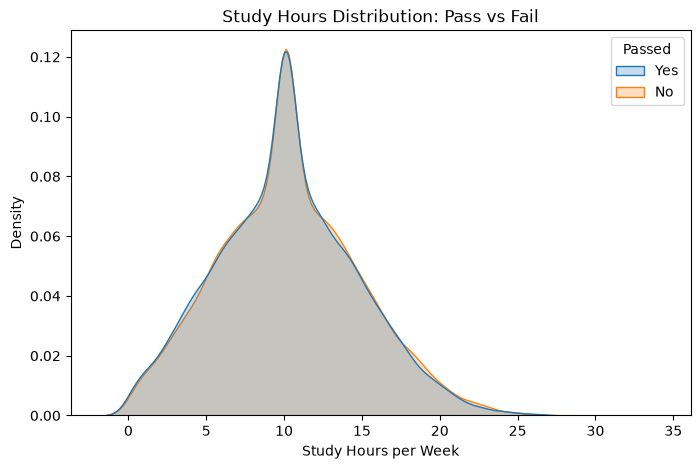

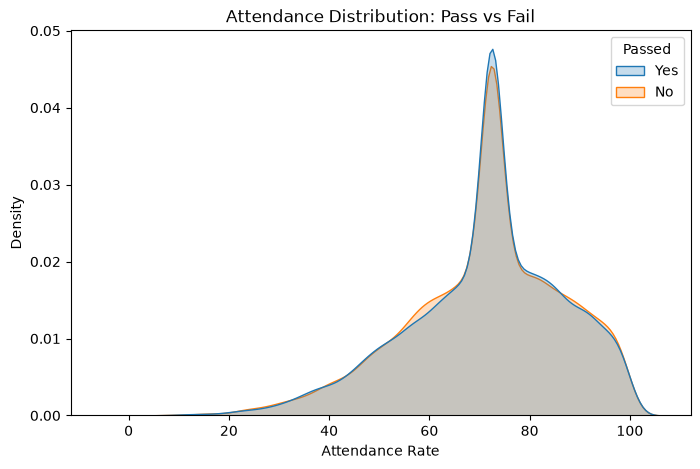

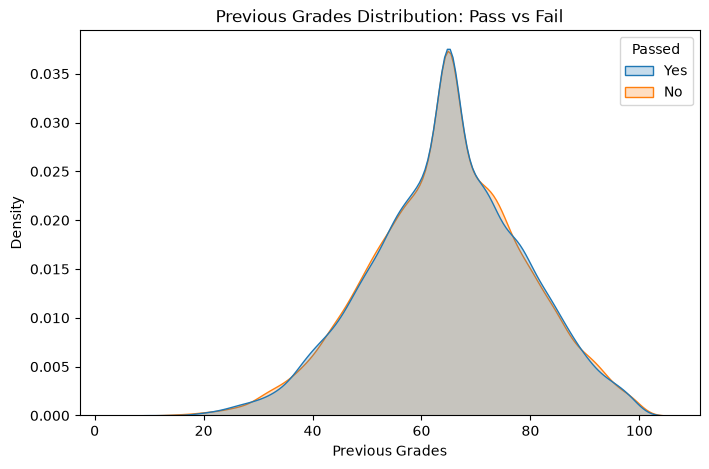


===== PASS RATE BY EXTRACURRICULAR ACTIVITY =====
Participation in Extracurricular Activities
No     50.02
Yes    50.04
Name: Passed_Binary, dtype: float64

===== PASS RATE BY PARENT EDUCATION =====
Parent Education Level
Doctorate      50.80
Bachelor       50.21
High School    50.15
Master         49.70
Associate      49.23
Name: Passed_Binary, dtype: float64


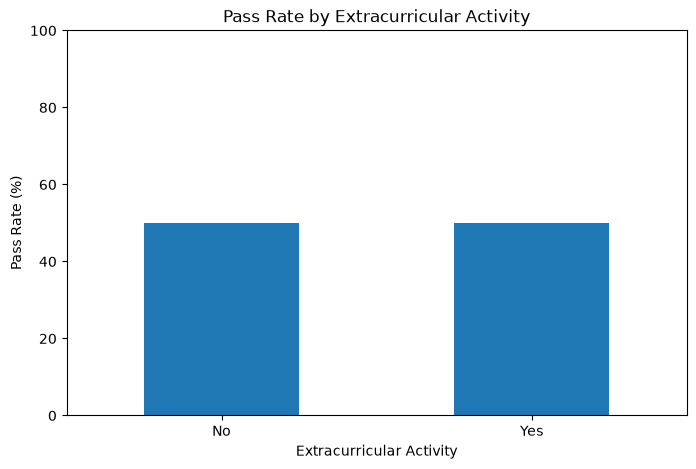

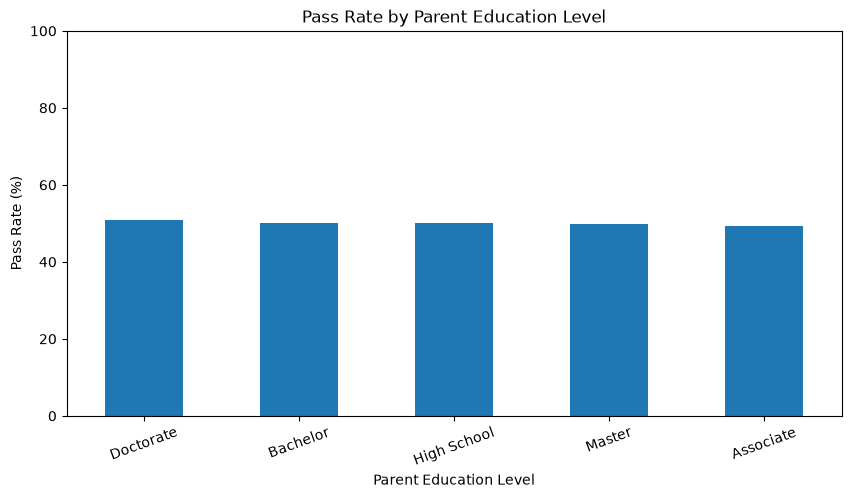

In [20]:
# ==========================================
# STEP 5: FEATURE VS TARGET ANALYSIS
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Create binary target for analysis
# ==========================================

df_analysis = df.copy()

df_analysis["Passed_Binary"] = (
    df_analysis["Passed"] == "Yes"
).astype(int)


# ==========================================
# 2. Numerical feature correlations
# ==========================================

numerical_columns = [
    "Study Hours per Week",
    "Attendance Rate",
    "Previous Grades"
]

print("===== CORRELATION WITH PASSED =====")

target_correlations = (
    df_analysis[
        numerical_columns + ["Passed_Binary"]
    ]
    .corr()["Passed_Binary"]
    .drop("Passed_Binary")
    .sort_values(ascending=False)
)

print(target_correlations)


# ==========================================
# 3. Average feature values by target
# ==========================================

print("\n===== AVERAGE FEATURES BY PASS/FAIL =====")

print(
    df_analysis
    .groupby("Passed")[numerical_columns]
    .mean()
    .round(3)
)


# ==========================================
# 4. Study Hours distribution by target
# ==========================================

plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=df_analysis,
    x="Study Hours per Week",
    hue="Passed",
    fill=True,
    common_norm=False
)

plt.title("Study Hours Distribution: Pass vs Fail")
plt.xlabel("Study Hours per Week")
plt.ylabel("Density")

plt.show()


# ==========================================
# 5. Attendance distribution by target
# ==========================================

plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=df_analysis,
    x="Attendance Rate",
    hue="Passed",
    fill=True,
    common_norm=False
)

plt.title("Attendance Distribution: Pass vs Fail")
plt.xlabel("Attendance Rate")
plt.ylabel("Density")

plt.show()


# ==========================================
# 6. Previous Grades distribution by target
# ==========================================

plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=df_analysis,
    x="Previous Grades",
    hue="Passed",
    fill=True,
    common_norm=False
)

plt.title("Previous Grades Distribution: Pass vs Fail")
plt.xlabel("Previous Grades")
plt.ylabel("Density")

plt.show()


# ==========================================
# 7. Pass percentage by extracurricular
# ==========================================

extra_pass_rate = (
    df_analysis
    .groupby("Participation in Extracurricular Activities")[
        "Passed_Binary"
    ]
    .mean()
    .mul(100)
    .round(2)
)

print("\n===== PASS RATE BY EXTRACURRICULAR ACTIVITY =====")
print(extra_pass_rate)


# ==========================================
# 8. Pass percentage by parent education
# ==========================================

parent_pass_rate = (
    df_analysis
    .groupby("Parent Education Level")[
        "Passed_Binary"
    ]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print("\n===== PASS RATE BY PARENT EDUCATION =====")
print(parent_pass_rate)


# ==========================================
# 9. Visualize pass rates
# ==========================================

plt.figure(figsize=(8, 5))

extra_pass_rate.plot(
    kind="bar"
)

plt.title("Pass Rate by Extracurricular Activity")
plt.xlabel("Extracurricular Activity")
plt.ylabel("Pass Rate (%)")
plt.ylim(0, 100)

plt.xticks(rotation=0)

plt.show()


plt.figure(figsize=(10, 5))

parent_pass_rate.plot(
    kind="bar"
)

plt.title("Pass Rate by Parent Education Level")
plt.xlabel("Parent Education Level")
plt.ylabel("Pass Rate (%)")
plt.ylim(0, 100)

plt.xticks(rotation=20)

plt.show()

here we don't have any correlation between any colounms with passed value , so we took a new dataset for our project .

===== DATASET SHAPE =====
(6607, 20)

===== COLUMN NAMES =====
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']

===== FIRST 5 ROWS =====
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0

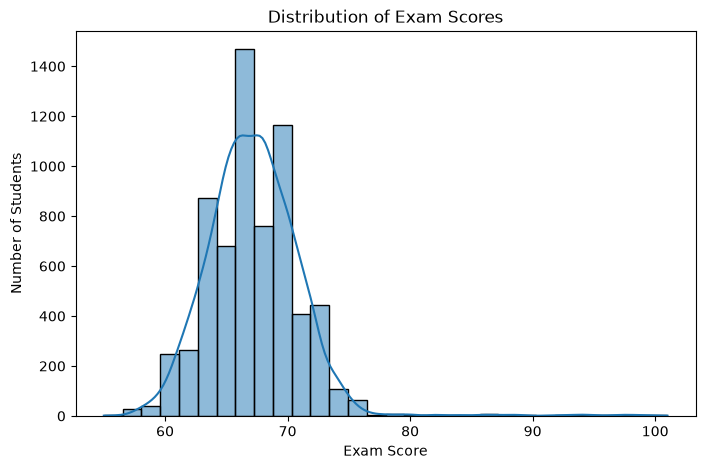

In [21]:
# ==========================================
# STEP 1: LOAD AND UNDERSTAND THE DATASET
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ==========================================
# 1. Load dataset
# ==========================================

df = pd.read_csv("../data/StudentPerformanceFactors.csv")


# ==========================================
# 2. Basic dataset information
# ==========================================

print("===== DATASET SHAPE =====")
print(df.shape)


print("\n===== COLUMN NAMES =====")
print(df.columns.tolist())


print("\n===== FIRST 5 ROWS =====")
print(df.head())


print("\n===== LAST 5 ROWS =====")
print(df.tail())


# ==========================================
# 3. Dataset information
# ==========================================

print("\n===== DATASET INFORMATION =====")
df.info()


# ==========================================
# 4. Statistical summary
# ==========================================

print("\n===== STATISTICAL SUMMARY =====")
print(df.describe(include="all"))


# ==========================================
# 5. Missing values
# ==========================================

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())


print("\n===== MISSING VALUE PERCENTAGE =====")
print(
    (df.isnull().sum() / len(df) * 100)
    .round(2)
)


# ==========================================
# 6. Duplicate rows
# ==========================================

print("\n===== DUPLICATE ROWS =====")
print(df.duplicated().sum())


# ==========================================
# 7. Separate numerical and categorical columns
# ==========================================

numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = df.select_dtypes(
    exclude=np.number
).columns.tolist()


print("\n===== NUMERICAL COLUMNS =====")
print(numerical_columns)


print("\n===== CATEGORICAL COLUMNS =====")
print(categorical_columns)


# ==========================================
# 8. Unique values in categorical columns
# ==========================================

print("\n===== CATEGORICAL VALUE COUNTS =====")

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts(dropna=False))


# ==========================================
# 9. Target information
# ==========================================

target = "Exam_Score"

print("\n===== TARGET: EXAM SCORE =====")

print("Minimum :", df[target].min())
print("Maximum :", df[target].max())
print("Mean    :", round(df[target].mean(), 2))
print("Median  :", df[target].median())
print("Std Dev :", round(df[target].std(), 2))


# ==========================================
# 10. Target distribution
# ==========================================

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x=target,
    bins=30,
    kde=True
)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")

plt.show()

In [22]:
# ==========================================
# STEP 2: DATA QUALITY CHECK
# ==========================================

import pandas as pd
import numpy as np

# ==========================================
# 1. Check invalid Exam Scores
# ==========================================

print("===== INVALID EXAM SCORES =====")

invalid_scores = (
    (df["Exam_Score"] < 0) |
    (df["Exam_Score"] > 100)
)

print("Number of invalid scores:", invalid_scores.sum())

if invalid_scores.sum() > 0:
    print("\nInvalid score values:")
    print(df.loc[invalid_scores, ["Exam_Score"]])


# ==========================================
# 2. Check numerical feature ranges
# ==========================================

print("\n===== NUMERICAL FEATURE RANGES =====")

numerical_features = [
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Physical_Activity",
    "Exam_Score"
]

for column in numerical_features:

    print(f"\n{column}")

    print("Minimum :", df[column].min())
    print("Maximum :", df[column].max())
    print("Mean    :", round(df[column].mean(), 2))
    print("Median  :", df[column].median())


# ==========================================
# 3. Check missing values
# ==========================================

print("\n===== MISSING VALUES =====")

missing = df.isnull().sum()

print(
    missing[missing > 0]
)


# ==========================================
# 4. Check percentage of missing values
# ==========================================

print("\n===== MISSING VALUE PERCENTAGE =====")

missing_percentage = (
    df.isnull().sum() / len(df) * 100
).round(2)

print(
    missing_percentage[missing_percentage > 0]
)


# ==========================================
# 5. Check duplicate rows
# ==========================================

print("\n===== DUPLICATE ROWS =====")

print(
    "Duplicate rows:",
    df.duplicated().sum()
)


# ==========================================
# 6. Check categorical values
# ==========================================

print("\n===== CATEGORICAL VALUES =====")

categorical_features = df.select_dtypes(
    exclude=np.number
).columns

for column in categorical_features:

    print(f"\n{column}:")
    print(
        df[column]
        .value_counts(dropna=False)
    )


# ==========================================
# 7. Final dataset summary
# ==========================================

print("\n===== FINAL SUMMARY =====")

print("Rows              :", len(df))
print("Columns           :", len(df.columns))
print("Missing cells     :", df.isnull().sum().sum())
print("Duplicate rows    :", df.duplicated().sum())
print("Invalid scores    :", invalid_scores.sum())

===== INVALID EXAM SCORES =====
Number of invalid scores: 1

Invalid score values:
      Exam_Score
1525         101

===== NUMERICAL FEATURE RANGES =====

Hours_Studied
Minimum : 1
Maximum : 44
Mean    : 19.98
Median  : 20.0

Attendance
Minimum : 60
Maximum : 100
Mean    : 79.98
Median  : 80.0

Sleep_Hours
Minimum : 4
Maximum : 10
Mean    : 7.03
Median  : 7.0

Previous_Scores
Minimum : 50
Maximum : 100
Mean    : 75.07
Median  : 75.0

Tutoring_Sessions
Minimum : 0
Maximum : 8
Mean    : 1.49
Median  : 1.0

Physical_Activity
Minimum : 0
Maximum : 6
Mean    : 2.97
Median  : 3.0

Exam_Score
Minimum : 55
Maximum : 101
Mean    : 67.24
Median  : 67.0

===== MISSING VALUES =====
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

===== MISSING VALUE PERCENTAGE =====
Teacher_Quality             1.18
Parental_Education_Level    1.36
Distance_from_Home          1.01
dtype: float64

===== DUPLICATE ROWS =====
Duplicate rows: 0

===== CATEGORIC

In [23]:
# ==========================================
# STEP 3: CLEAN THE DATASET
# ==========================================

import pandas as pd
import numpy as np


# ==========================================
# 1. Make a copy of the original dataset
# ==========================================

clean_df = df.copy()


# ==========================================
# 2. Handle invalid Exam Scores
# ==========================================

# Exam scores should be between 0 and 100.
# Any score above 100 is considered invalid.

clean_df.loc[
    (clean_df["Exam_Score"] < 0) |
    (clean_df["Exam_Score"] > 100),
    "Exam_Score"
] = np.nan


# ==========================================
# 3. Check how many target values are missing
# ==========================================

print("Missing Exam Scores after validation:")
print(clean_df["Exam_Score"].isnull().sum())


# ==========================================
# 4. Handle missing categorical values
# ==========================================

categorical_columns = [
    "Teacher_Quality",
    "Parental_Education_Level",
    "Distance_from_Home"
]

for column in categorical_columns:

    # Find the most common value
    mode_value = clean_df[column].mode()[0]

    # Replace missing values with the mode
    clean_df[column] = clean_df[column].fillna(mode_value)


# ==========================================
# 5. Verify missing values
# ==========================================

print("\n===== MISSING VALUES AFTER CLEANING =====")

missing_values = clean_df.isnull().sum()

print(
    missing_values[missing_values > 0]
)


# ==========================================
# 6. Verify Exam Score range
# ==========================================

print("\n===== EXAM SCORE AFTER CLEANING =====")

print("Minimum :", clean_df["Exam_Score"].min())
print("Maximum :", clean_df["Exam_Score"].max())
print("Mean    :", round(clean_df["Exam_Score"].mean(), 2))
print("Median  :", clean_df["Exam_Score"].median())


# ==========================================
# 7. Check duplicates
# ==========================================

print("\n===== DUPLICATES AFTER CLEANING =====")

print(
    clean_df.duplicated().sum()
)


# ==========================================
# 8. Final dataset shape
# ==========================================

print("\n===== CLEANED DATASET SHAPE =====")

print(clean_df.shape)


# ==========================================
# 9. Display cleaned dataset
# ==========================================

print("\n===== FIRST 5 CLEANED ROWS =====")

print(clean_df.head())


# ==========================================
# 10. Save cleaned dataset
# ==========================================

clean_df.to_csv(
    "../data/StudentPerformanceFactors_Cleaned.csv",
    index=False
)

print(
    "\nCleaned dataset saved successfully!"
)

Missing Exam Scores after validation:
1

===== MISSING VALUES AFTER CLEANING =====
Exam_Score    1
dtype: int64

===== EXAM SCORE AFTER CLEANING =====
Minimum : 55.0
Maximum : 100.0
Mean    : 67.23
Median  : 67.0

===== DUPLICATES AFTER CLEANING =====
0

===== CLEANED DATASET SHAPE =====
(6607, 20)

===== FIRST 5 CLEANED ROWS =====
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59           

===== EXAM SCORE STATISTICS =====
Count  : 6606
Mean   : 67.23
Median : 67.0
Std    : 3.87
Min    : 55.0
Max    : 100.0


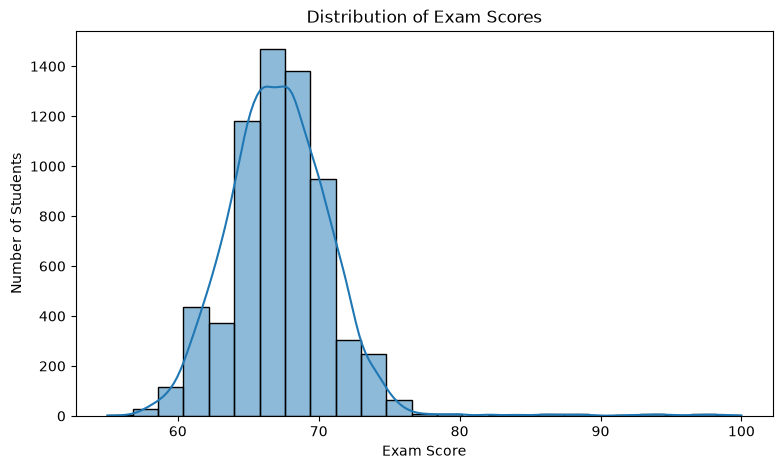


===== CORRELATION WITH EXAM SCORE =====
Attendance           0.582
Hours_Studied        0.447
Previous_Scores      0.174
Tutoring_Sessions    0.154
Physical_Activity    0.028
Sleep_Hours         -0.016
Name: Exam_Score, dtype: float64


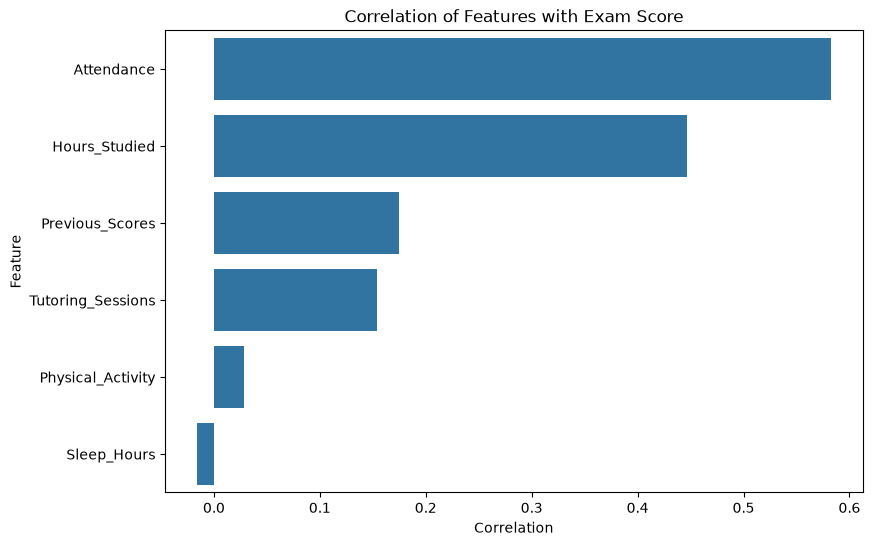

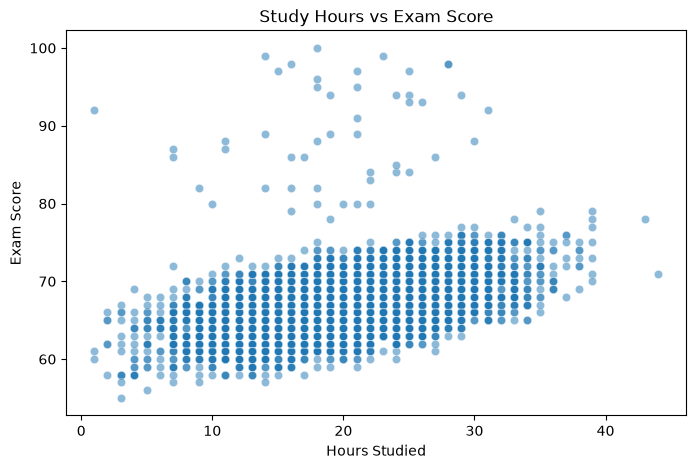

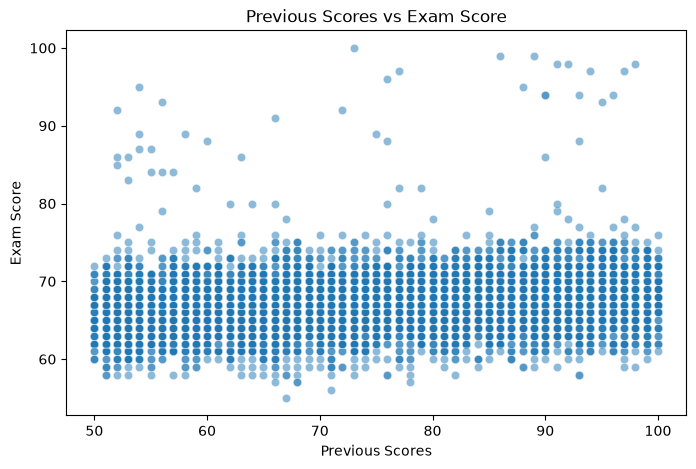

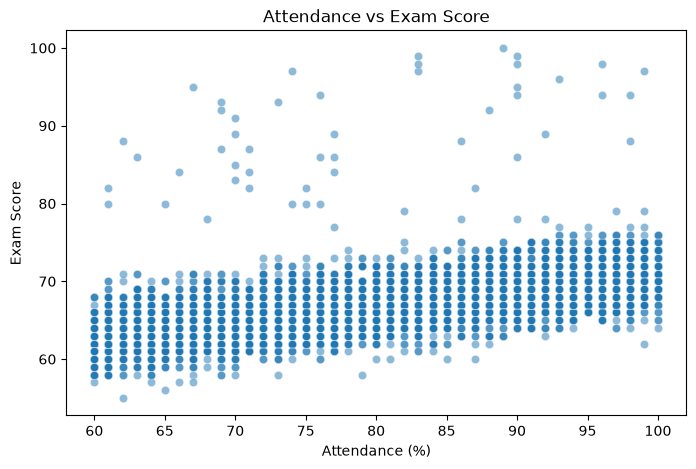

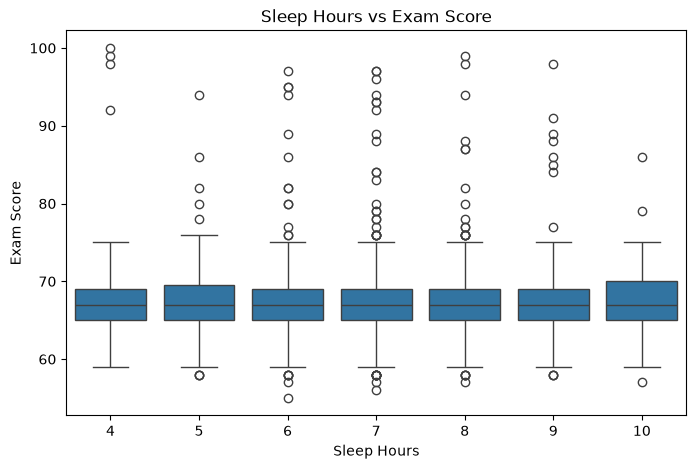

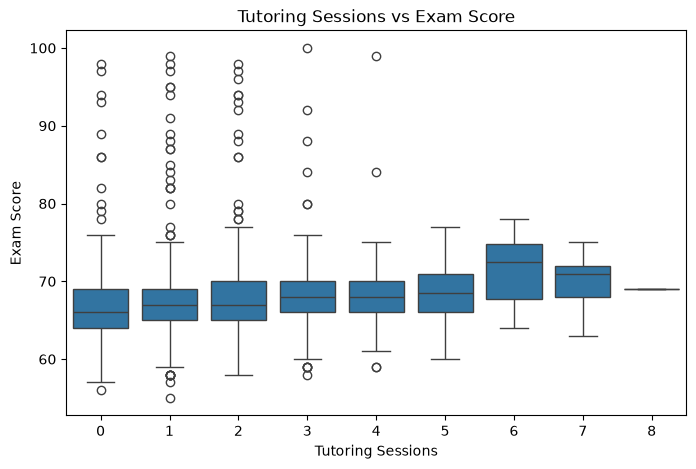

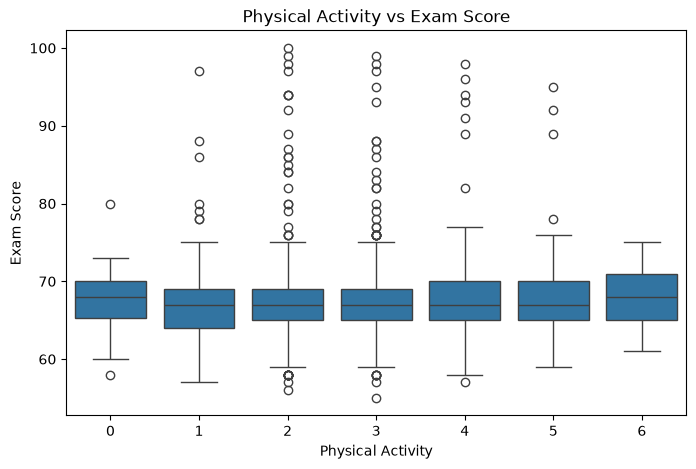

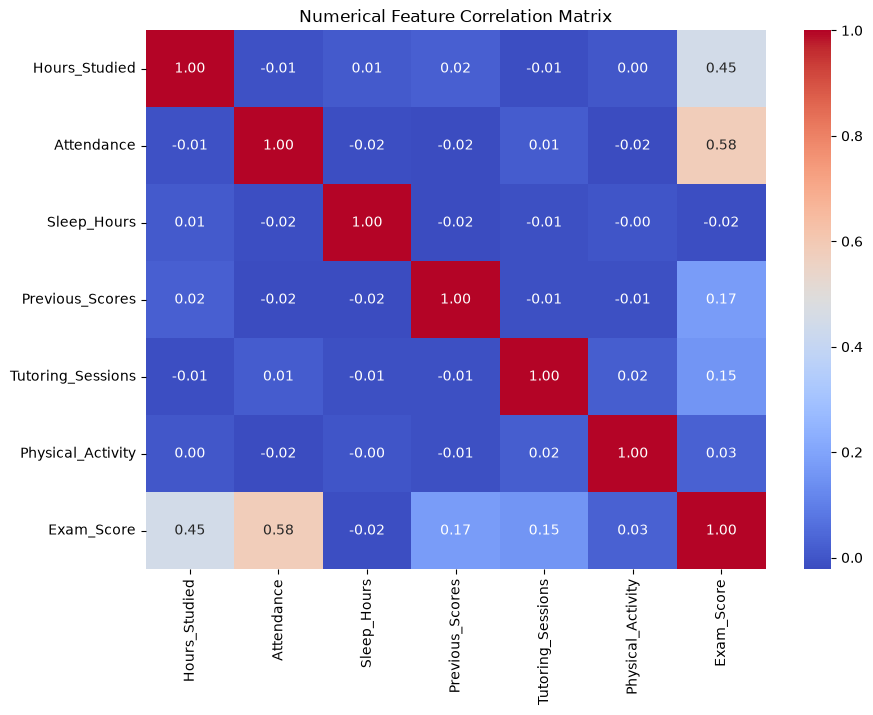

In [24]:
# ==========================================
# STEP 4: EXPLORATORY DATA ANALYSIS
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ==========================================
# 1. Remove the one row with missing target
# ==========================================

clean_df = clean_df.dropna(subset=["Exam_Score"]).copy()


# ==========================================
# 2. Basic target statistics
# ==========================================

print("===== EXAM SCORE STATISTICS =====")

print("Count  :", len(clean_df))
print("Mean   :", round(clean_df["Exam_Score"].mean(), 2))
print("Median :", clean_df["Exam_Score"].median())
print("Std    :", round(clean_df["Exam_Score"].std(), 2))
print("Min    :", clean_df["Exam_Score"].min())
print("Max    :", clean_df["Exam_Score"].max())


# ==========================================
# 3. Distribution of Exam Scores
# ==========================================

plt.figure(figsize=(9, 5))

sns.histplot(
    data=clean_df,
    x="Exam_Score",
    bins=25,
    kde=True
)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")

plt.show()


# ==========================================
# 4. Numerical features
# ==========================================

numerical_features = [
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Physical_Activity"
]


# ==========================================
# 5. Correlation with Exam Score
# ==========================================

print("\n===== CORRELATION WITH EXAM SCORE =====")

correlation_with_target = (
    clean_df[numerical_features + ["Exam_Score"]]
    .corr()["Exam_Score"]
    .drop("Exam_Score")
    .sort_values(ascending=False)
)

print(correlation_with_target.round(3))


# ==========================================
# 6. Visualize correlations
# ==========================================

plt.figure(figsize=(9, 6))

sns.barplot(
    x=correlation_with_target.values,
    y=correlation_with_target.index
)

plt.title("Correlation of Features with Exam Score")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.show()


# ==========================================
# 7. Study Hours vs Exam Score
# ==========================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=clean_df,
    x="Hours_Studied",
    y="Exam_Score",
    alpha=0.5
)

plt.title("Study Hours vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.show()


# ==========================================
# 8. Previous Scores vs Exam Score
# ==========================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=clean_df,
    x="Previous_Scores",
    y="Exam_Score",
    alpha=0.5
)

plt.title("Previous Scores vs Exam Score")
plt.xlabel("Previous Scores")
plt.ylabel("Exam Score")

plt.show()


# ==========================================
# 9. Attendance vs Exam Score
# ==========================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=clean_df,
    x="Attendance",
    y="Exam_Score",
    alpha=0.5
)

plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Exam Score")

plt.show()


# ==========================================
# 10. Sleep Hours vs Exam Score
# ==========================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=clean_df,
    x="Sleep_Hours",
    y="Exam_Score"
)

plt.title("Sleep Hours vs Exam Score")
plt.xlabel("Sleep Hours")
plt.ylabel("Exam Score")

plt.show()


# ==========================================
# 11. Tutoring Sessions vs Exam Score
# ==========================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=clean_df,
    x="Tutoring_Sessions",
    y="Exam_Score"
)

plt.title("Tutoring Sessions vs Exam Score")
plt.xlabel("Tutoring Sessions")
plt.ylabel("Exam Score")

plt.show()


# ==========================================
# 12. Physical Activity vs Exam Score
# ==========================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=clean_df,
    x="Physical_Activity",
    y="Exam_Score"
)

plt.title("Physical Activity vs Exam Score")
plt.xlabel("Physical Activity")
plt.ylabel("Exam Score")

plt.show()


# ==========================================
# 13. Full numerical correlation matrix
# ==========================================

plt.figure(figsize=(10, 7))

correlation_matrix = clean_df[
    numerical_features + ["Exam_Score"]
].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Numerical Feature Correlation Matrix")

plt.show()

===== CATEGORICAL FEATURES =====
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

===== MISSING COLUMN NAMES =====
[]

===== AVERAGE EXAM SCORE BY CATEGORY =====

--- Parental_Involvement ---
                       mean  median  count
Parental_Involvement                      
High                  68.09    68.0   1908
Medium                67.10    67.0   3362
Low                   66.33    66.0   1336

--- Access_to_Resources ---
                      mean  median  count
Access_to_Resources                      
High                 68.09    68.0   1975
Medium               67.12    67.0   3318
Low                  66.20    66.0   1313

--- Extracurricular_Activities ---
                             mean  median  count
Extracurricular_Activities                    

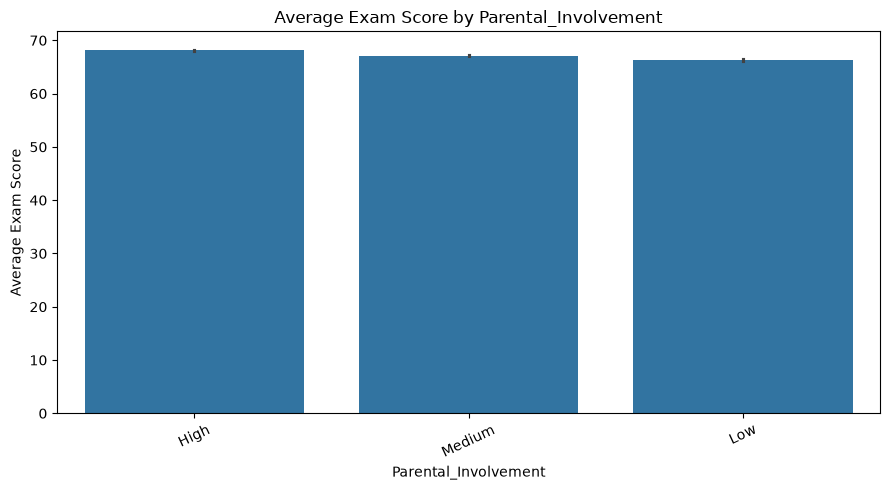

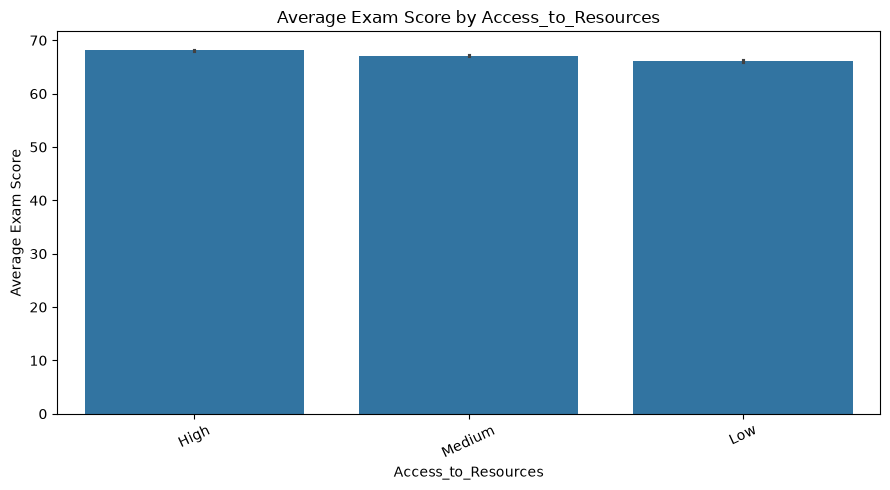

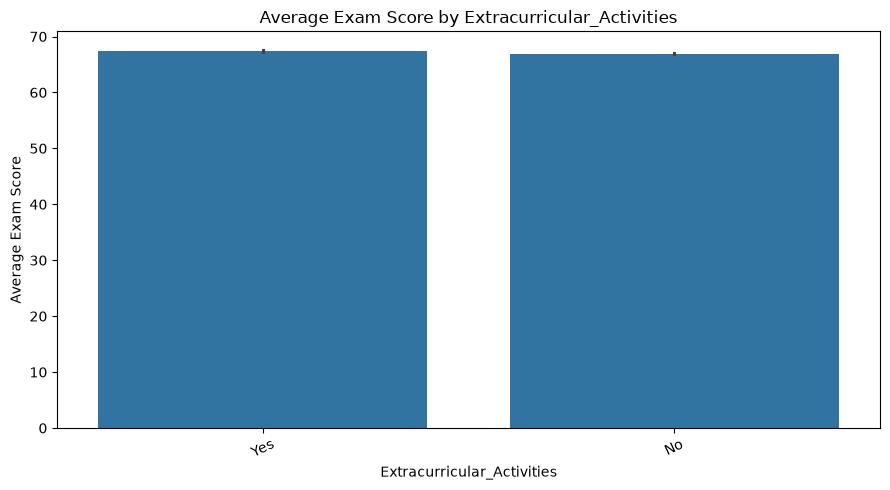

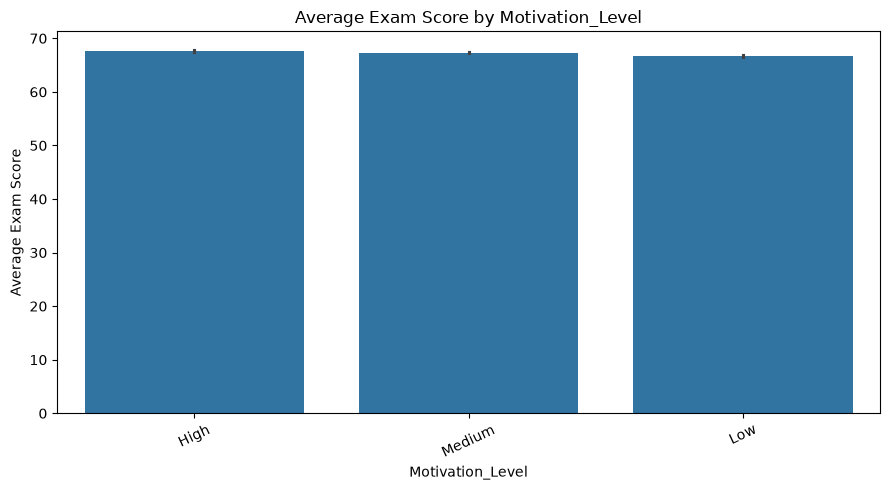

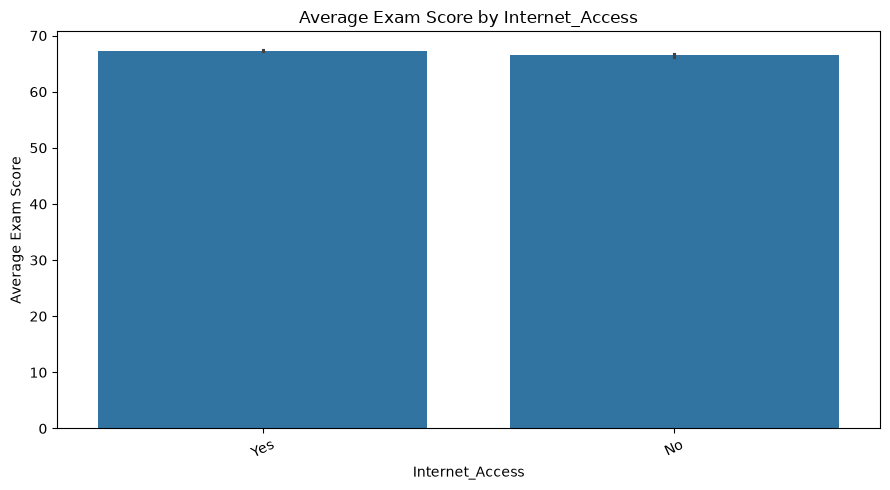

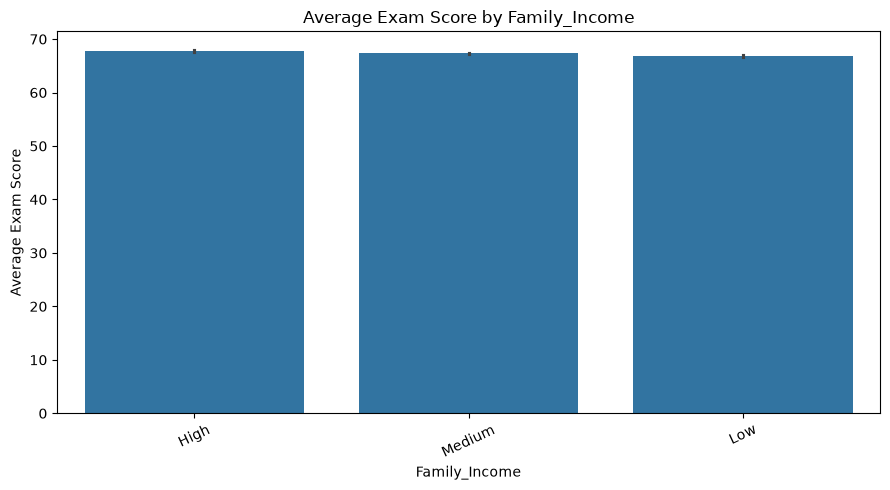

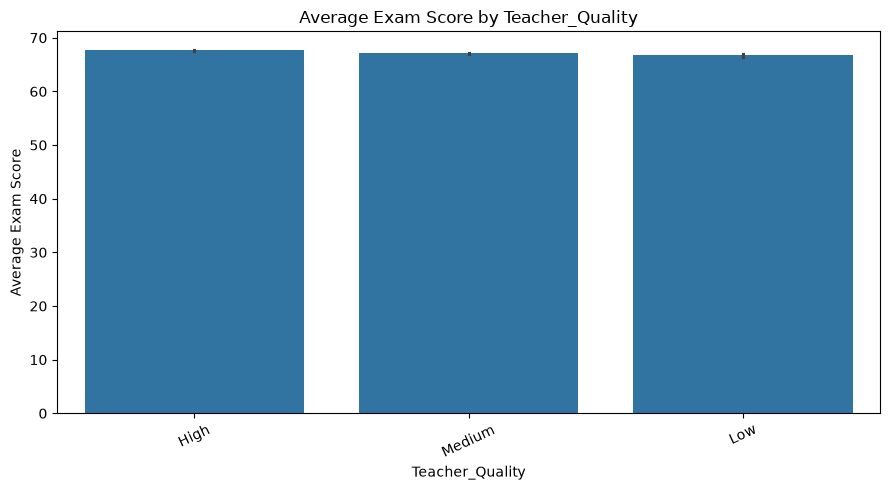

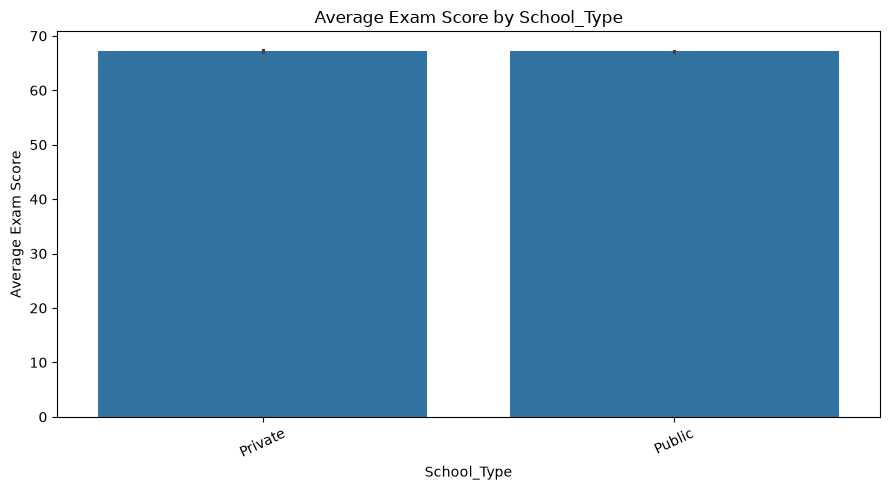

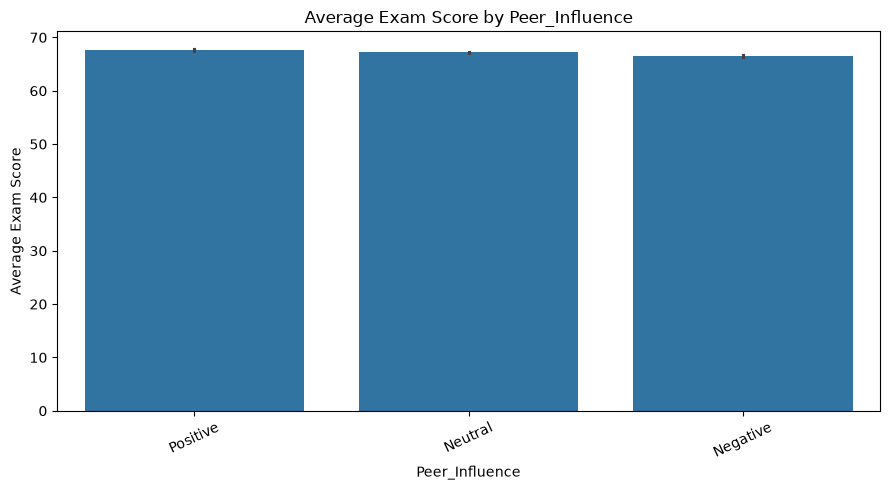

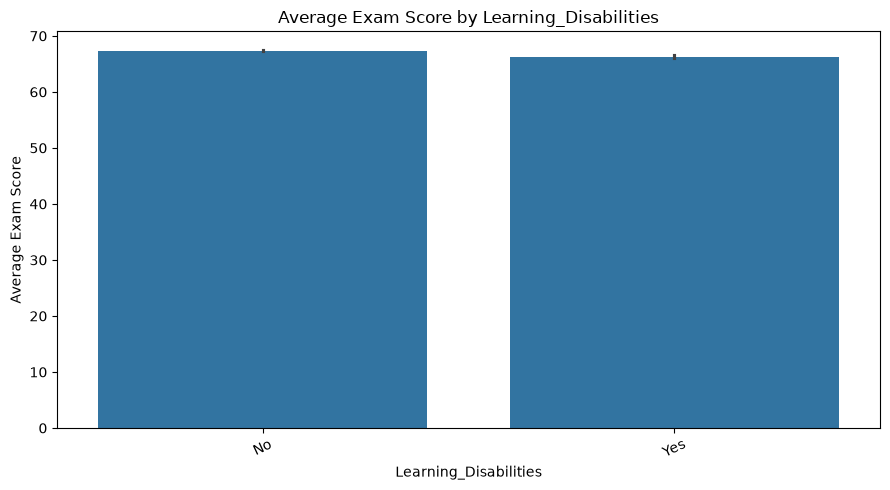

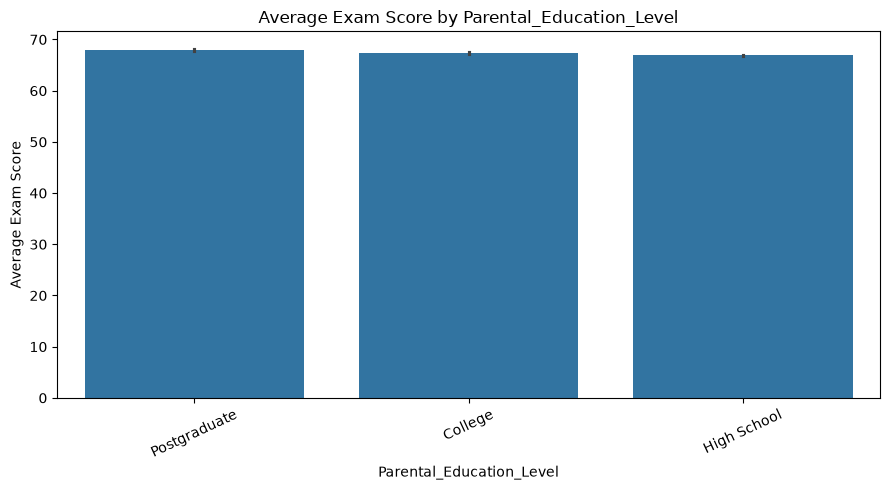

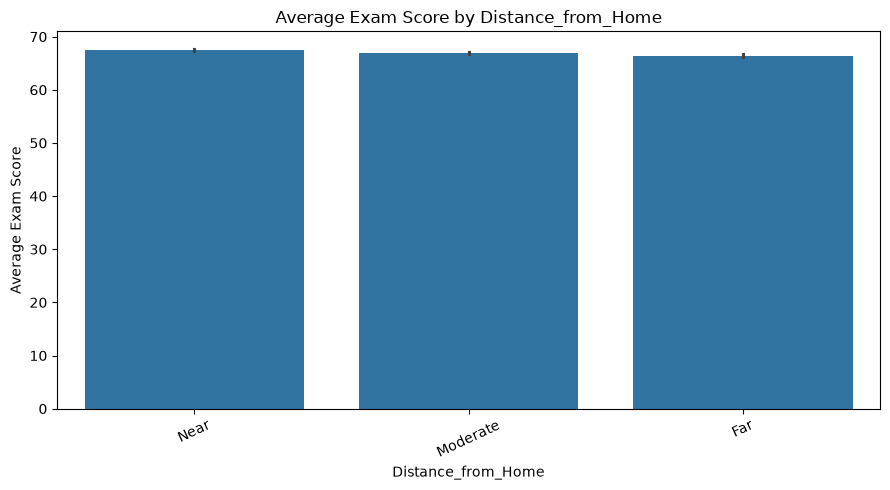

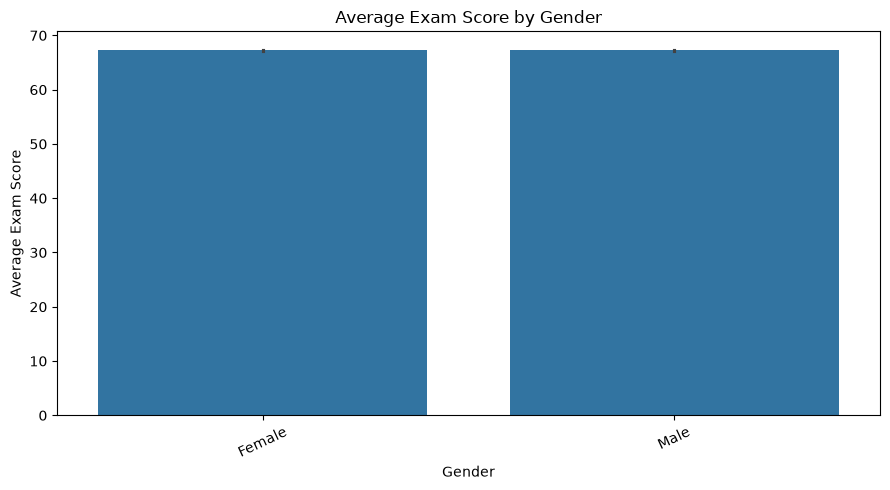


===== CATEGORICAL ANALYSIS COMPLETE =====
Analyzed 13 categorical features.


In [26]:
# ==========================================
# STEP 5: CATEGORICAL FEATURE ANALYSIS
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ==========================================
# 1. Explicitly define categorical features
# ==========================================

categorical_features = [
    "Parental_Involvement",
    "Access_to_Resources",
    "Extracurricular_Activities",
    "Motivation_Level",
    "Internet_Access",
    "Family_Income",
    "Teacher_Quality",
    "School_Type",
    "Peer_Influence",
    "Learning_Disabilities",
    "Parental_Education_Level",
    "Distance_from_Home",
    "Gender"
]


print("===== CATEGORICAL FEATURES =====")
print(categorical_features)


# ==========================================
# 2. Check that all columns exist
# ==========================================

missing_columns = [
    column
    for column in categorical_features
    if column not in clean_df.columns
]

print("\n===== MISSING COLUMN NAMES =====")
print(missing_columns)


# ==========================================
# 3. Average Exam Score for each category
# ==========================================

print("\n===== AVERAGE EXAM SCORE BY CATEGORY =====")

for column in categorical_features:

    print(f"\n--- {column} ---")

    result = (
        clean_df
        .groupby(column)["Exam_Score"]
        .agg(["mean", "median", "count"])
        .sort_values("mean", ascending=False)
    )

    print(result.round(2))


# ==========================================
# 4. Visualize categorical features
# ==========================================

for column in categorical_features:

    plt.figure(figsize=(9, 5))

    order = (
        clean_df
        .groupby(column)["Exam_Score"]
        .mean()
        .sort_values(ascending=False)
        .index
    )

    sns.barplot(
        data=clean_df,
        x=column,
        y="Exam_Score",
        order=order
    )

    plt.title(f"Average Exam Score by {column}")
    plt.xlabel(column)
    plt.ylabel("Average Exam Score")

    plt.xticks(rotation=25)

    plt.tight_layout()
    plt.show()


# ==========================================
# 5. Overall summary
# ==========================================

print("\n===== CATEGORICAL ANALYSIS COMPLETE =====")
print(
    "Analyzed",
    len(categorical_features),
    "categorical features."
)

In [27]:
# ==========================================
# STEP 6: TRAIN/TEST SPLIT + PREPROCESSING
# ==========================================

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer


# ==========================================
# 1. Separate features and target
# ==========================================

X = clean_df.drop(columns=["Exam_Score"])

y = clean_df["Exam_Score"]


print("===== FEATURES =====")
print(X.head())


print("\n===== TARGET =====")
print(y.head())


# ==========================================
# 2. Define numerical features
# ==========================================

numerical_features = [
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Physical_Activity"
]


# ==========================================
# 3. Define categorical features
# ==========================================

categorical_features = [
    "Parental_Involvement",
    "Access_to_Resources",
    "Extracurricular_Activities",
    "Motivation_Level",
    "Internet_Access",
    "Family_Income",
    "Teacher_Quality",
    "School_Type",
    "Peer_Influence",
    "Learning_Disabilities",
    "Parental_Education_Level",
    "Distance_from_Home",
    "Gender"
]


# ==========================================
# 4. Train/Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


print("\n===== DATA SPLIT =====")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


# ==========================================
# 5. Numerical preprocessing
# ==========================================

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)


# ==========================================
# 6. Categorical preprocessing
# ==========================================

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


# ==========================================
# 7. Combine preprocessing
# ==========================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)


# ==========================================
# 8. Fit preprocessing on training data
# ==========================================

X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)


# ==========================================
# 9. Check processed data
# ==========================================

print("\n===== PROCESSED DATA =====")

print(
    "X_train before preprocessing:",
    X_train.shape
)

print(
    "X_train after preprocessing:",
    X_train_processed.shape
)

print(
    "X_test before preprocessing:",
    X_test.shape
)

print(
    "X_test after preprocessing:",
    X_test_processed.shape
)


# ==========================================
# 10. Get encoded feature names
# ==========================================

feature_names = (
    preprocessor
    .get_feature_names_out()
)


print("\n===== FEATURE COUNT =====")
print(
    "Total features after encoding:",
    len(feature_names)
)


print("\n===== FIRST 30 FEATURES =====")

for feature in feature_names[:30]:
    print(feature)

===== FEATURES =====
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Qualit

===== LINEAR REGRESSION RESULTS =====
MAE  : 0.4160
MSE  : 2.3142
RMSE : 1.5213
R²   : 0.8250

===== ACTUAL VS PREDICTED =====
    Actual Score  Predicted Score
0           66.0            66.01
1           66.0            65.45
2           67.0            67.58
3           67.0            67.65
4           68.0            68.01
5           63.0            63.25
6           74.0            74.01
7           65.0            65.07
8           69.0            68.97
9           76.0            75.71
10          70.0            69.94
11          62.0            62.01
12          65.0            65.31
13          68.0            68.51
14          72.0            71.84
15          67.0            67.69
16          70.0            70.51
17          70.0            70.26
18          66.0            66.24
19          67.0            67.18

===== ERROR STATISTICS =====
count    1322.00
mean       -0.10
std         1.52
min        -1.14
25%        -0.46
50%        -0.18
75%         0.09
max       

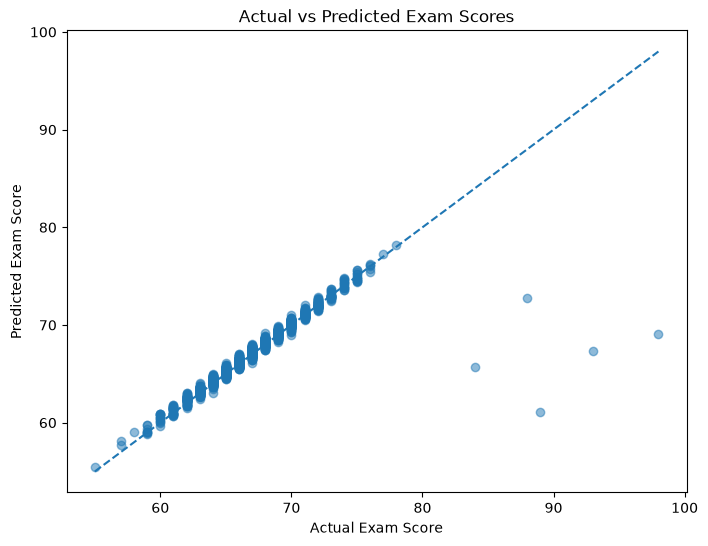

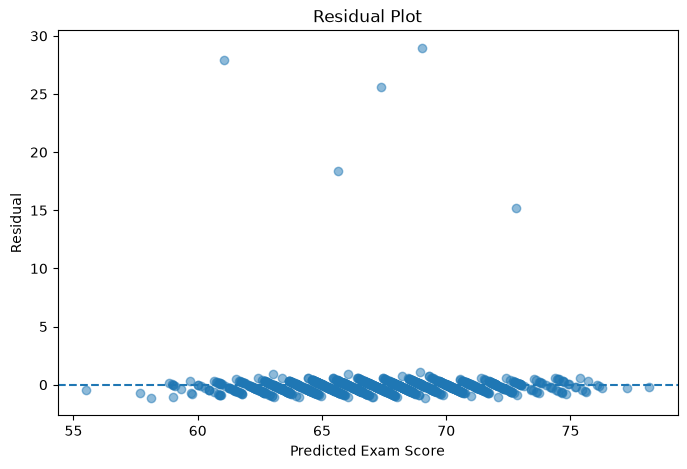

In [28]:
# ==========================================
# STEP 7: LINEAR REGRESSION
# ==========================================

import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ==========================================
# 1. Create the Linear Regression model
# ==========================================

linear_model = LinearRegression()


# ==========================================
# 2. Train the model
# ==========================================

linear_model.fit(
    X_train_processed,
    y_train
)


# ==========================================
# 3. Make predictions
# ==========================================

y_pred = linear_model.predict(
    X_test_processed
)


# ==========================================
# 4. Calculate evaluation metrics
# ==========================================

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)


# ==========================================
# 5. Display results
# ==========================================

print("===== LINEAR REGRESSION RESULTS =====")

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


# ==========================================
# 6. Compare actual vs predicted
# ==========================================

comparison = pd.DataFrame({
    "Actual Score": y_test.values,
    "Predicted Score": y_pred
})

print("\n===== ACTUAL VS PREDICTED =====")
print(comparison.head(20).round(2))


# ==========================================
# 7. Prediction error
# ==========================================

comparison["Error"] = (
    comparison["Actual Score"]
    - comparison["Predicted Score"]
)

print("\n===== ERROR STATISTICS =====")

print(
    comparison["Error"]
    .describe()
    .round(2)
)


# ==========================================
# 8. Actual vs Predicted plot
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

# Perfect prediction line
min_score = min(
    y_test.min(),
    y_pred.min()
)

max_score = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [min_score, max_score],
    [min_score, max_score],
    linestyle="--"
)

plt.title("Actual vs Predicted Exam Scores")
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")

plt.show()


# ==========================================
# 9. Residual plot
# ==========================================

residuals = (
    y_test - y_pred
)

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residual Plot")
plt.xlabel("Predicted Exam Score")
plt.ylabel("Residual")

plt.show()

===== DECISION TREE RESULTS =====
MAE  : 1.5471
MSE  : 6.3345
RMSE : 2.5168
R²   : 0.5210

===== MODEL COMPARISON =====
               Model     MAE    RMSE     R²
0  Linear Regression  0.4160  1.5213  0.825
1      Decision Tree  1.5471  2.5168  0.521


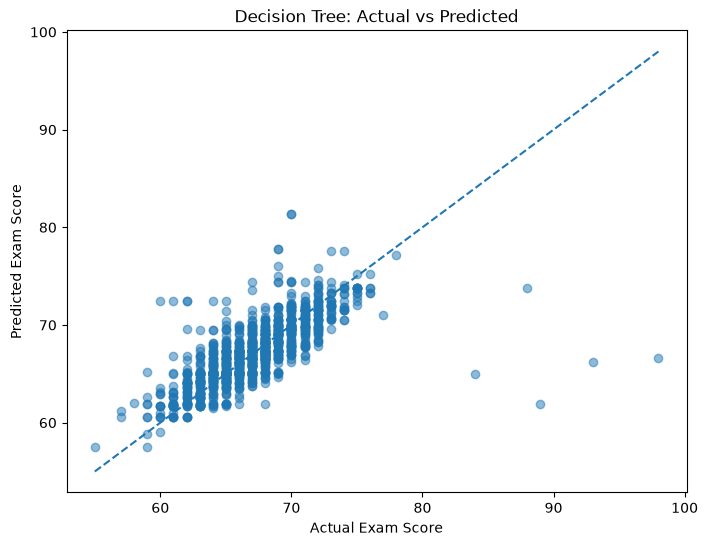

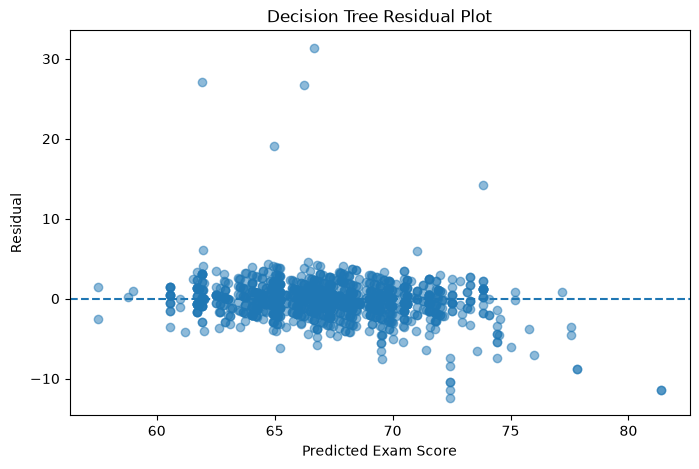

In [29]:
# ==========================================
# STEP 8: DECISION TREE REGRESSION
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ==========================================
# 1. Create Decision Tree model
# ==========================================

tree_model = DecisionTreeRegressor(
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)


# ==========================================
# 2. Train the model
# ==========================================

tree_model.fit(
    X_train_processed,
    y_train
)


# ==========================================
# 3. Make predictions
# ==========================================

tree_pred = tree_model.predict(
    X_test_processed
)


# ==========================================
# 4. Calculate metrics
# ==========================================

tree_mae = mean_absolute_error(
    y_test,
    tree_pred
)

tree_mse = mean_squared_error(
    y_test,
    tree_pred
)

tree_rmse = np.sqrt(tree_mse)

tree_r2 = r2_score(
    y_test,
    tree_pred
)


# ==========================================
# 5. Display results
# ==========================================

print("===== DECISION TREE RESULTS =====")

print(f"MAE  : {tree_mae:.4f}")
print(f"MSE  : {tree_mse:.4f}")
print(f"RMSE : {tree_rmse:.4f}")
print(f"R²   : {tree_r2:.4f}")


# ==========================================
# 6. Compare with Linear Regression
# ==========================================

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree"
    ],
    "MAE": [
        mae,
        tree_mae
    ],
    "RMSE": [
        rmse,
        tree_rmse
    ],
    "R²": [
        r2,
        tree_r2
    ]
})


print("\n===== MODEL COMPARISON =====")
print(
    comparison.round(4)
)


# ==========================================
# 7. Actual vs Predicted
# ==========================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    tree_pred,
    alpha=0.5
)

min_score = min(
    y_test.min(),
    tree_pred.min()
)

max_score = max(
    y_test.max(),
    tree_pred.max()
)

plt.plot(
    [min_score, max_score],
    [min_score, max_score],
    linestyle="--"
)

plt.title("Decision Tree: Actual vs Predicted")
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")

plt.show()


# ==========================================
# 8. Residual plot
# ==========================================

tree_residuals = (
    y_test - tree_pred
)

plt.figure(figsize=(8, 5))

plt.scatter(
    tree_pred,
    tree_residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Decision Tree Residual Plot")
plt.xlabel("Predicted Exam Score")
plt.ylabel("Residual")

plt.show()

===== RANDOM FOREST RESULTS =====
MAE  : 1.0605
MSE  : 3.6978
RMSE : 1.9230
R²   : 0.7204

===== ALL MODEL COMPARISON =====
               Model     MAE    RMSE      R²
0  Linear Regression  0.4160  1.5213  0.8250
2      Random Forest  1.0605  1.9230  0.7204
1      Decision Tree  1.5471  2.5168  0.5210


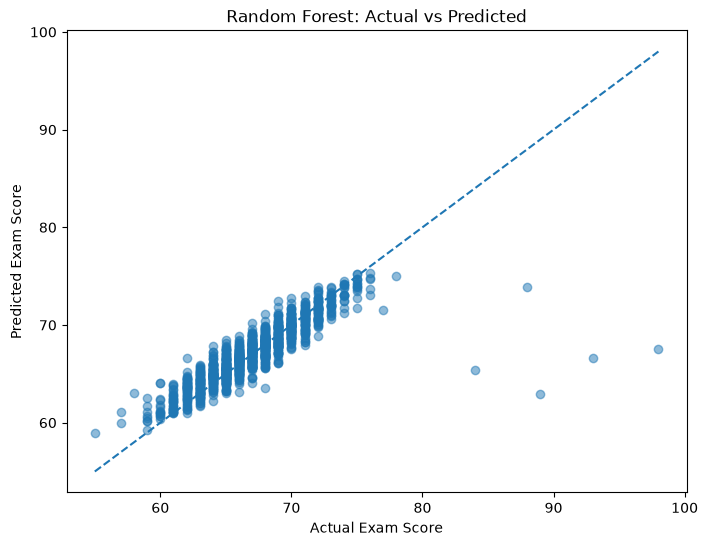

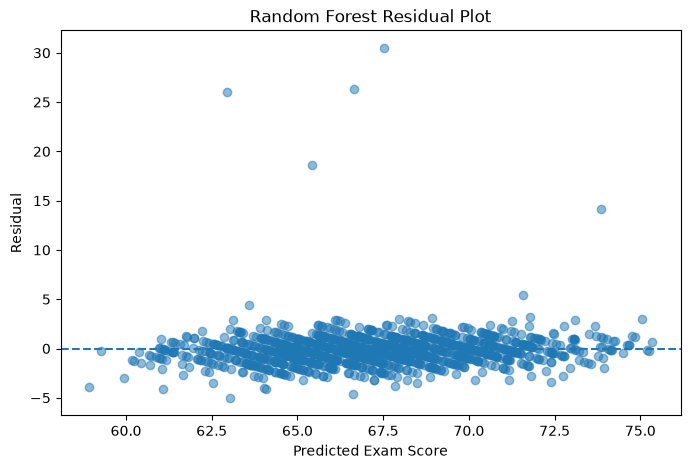

In [30]:
# ==========================================
# STEP 9: RANDOM FOREST REGRESSION
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ==========================================
# 1. Create Random Forest model
# ==========================================

random_forest_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)


# ==========================================
# 2. Train the model
# ==========================================

random_forest_model.fit(
    X_train_processed,
    y_train
)


# ==========================================
# 3. Make predictions
# ==========================================

rf_pred = random_forest_model.predict(
    X_test_processed
)


# ==========================================
# 4. Calculate evaluation metrics
# ==========================================

rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_mse = mean_squared_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(
    y_test,
    rf_pred
)


# ==========================================
# 5. Display Random Forest results
# ==========================================

print("===== RANDOM FOREST RESULTS =====")

print(f"MAE  : {rf_mae:.4f}")
print(f"MSE  : {rf_mse:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R²   : {rf_r2:.4f}")


# ==========================================
# 6. Compare all models
# ==========================================

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae,
        tree_mae,
        rf_mae
    ],
    "RMSE": [
        rmse,
        tree_rmse,
        rf_rmse
    ],
    "R²": [
        r2,
        tree_r2,
        rf_r2
    ]
})


print("\n===== ALL MODEL COMPARISON =====")

print(
    model_comparison
    .round(4)
    .sort_values("R²", ascending=False)
)


# ==========================================
# 7. Actual vs Predicted
# ==========================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.5
)

min_score = min(
    y_test.min(),
    rf_pred.min()
)

max_score = max(
    y_test.max(),
    rf_pred.max()
)

plt.plot(
    [min_score, max_score],
    [min_score, max_score],
    linestyle="--"
)

plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")

plt.show()


# ==========================================
# 8. Residual plot
# ==========================================

rf_residuals = (
    y_test - rf_pred
)

plt.figure(figsize=(8, 5))

plt.scatter(
    rf_pred,
    rf_residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Random Forest Residual Plot")
plt.xlabel("Predicted Exam Score")
plt.ylabel("Residual")

plt.show()

===== TOP 20 FEATURES BY COEFFICIENT =====
                                           Feature  Coefficient  Absolute_Coefficient
              categorical__Access_to_Resources_Low      -1.0503                1.0503
             categorical__Access_to_Resources_High       1.0441                1.0441
            categorical__Parental_Involvement_High       1.0342                1.0342
             categorical__Parental_Involvement_Low      -0.9854                0.9854
                categorical__Motivation_Level_High       0.5467                0.5467
                 categorical__Motivation_Level_Low      -0.5335                0.5335
                 categorical__Teacher_Quality_High       0.5262                0.5262
                   categorical__Family_Income_High       0.5216                0.5216
                  categorical__Teacher_Quality_Low      -0.5132                0.5132
 categorical__Parental_Education_Level_High School      -0.5127                0.5127
           

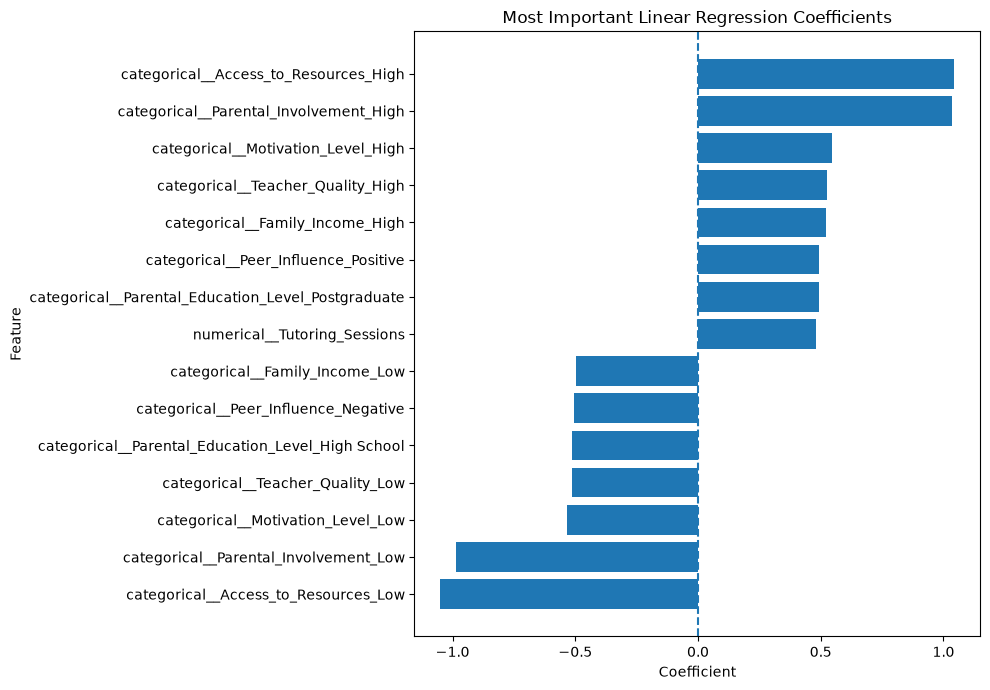

In [31]:
# ==========================================
# STEP 10: LINEAR REGRESSION COEFFICIENTS
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ==========================================
# 1. Get feature names
# ==========================================

feature_names = (
    preprocessor
    .get_feature_names_out()
)


# ==========================================
# 2. Get model coefficients
# ==========================================

coefficients = linear_model.coef_


# ==========================================
# 3. Create coefficient DataFrame
# ==========================================

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})


# ==========================================
# 4. Add absolute coefficient
# ==========================================

coefficient_df["Absolute_Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)


# ==========================================
# 5. Sort by importance
# ==========================================

coefficient_df = (
    coefficient_df
    .sort_values(
        "Absolute_Coefficient",
        ascending=False
    )
)


# ==========================================
# 6. Display top 20 features
# ==========================================

print("===== TOP 20 FEATURES BY COEFFICIENT =====")

print(
    coefficient_df
    .head(20)
    .round(4)
    .to_string(index=False)
)


# ==========================================
# 7. Positive and negative coefficients
# ==========================================

print("\n===== TOP POSITIVE COEFFICIENTS =====")

positive_coefficients = (
    coefficient_df
    .sort_values(
        "Coefficient",
        ascending=False
    )
    .head(10)
)

print(
    positive_coefficients[
        ["Feature", "Coefficient"]
    ]
    .round(4)
    .to_string(index=False)
)


print("\n===== TOP NEGATIVE COEFFICIENTS =====")

negative_coefficients = (
    coefficient_df
    .sort_values(
        "Coefficient",
        ascending=True
    )
    .head(10)
)

print(
    negative_coefficients[
        ["Feature", "Coefficient"]
    ]
    .round(4)
    .to_string(index=False)
)


# ==========================================
# 8. Plot most important coefficients
# ==========================================

top_features = (
    coefficient_df
    .head(15)
    .sort_values("Coefficient")
)


plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title(
    "Most Important Linear Regression Coefficients"
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

In [32]:
# ==========================================
# STEP 11: STUDENT SCORE PREDICTION SYSTEM
# ==========================================

import pandas as pd
import numpy as np


# ==========================================
# 1. Prediction function
# ==========================================

def predict_exam_score(
    hours_studied,
    attendance,
    sleep_hours,
    previous_scores,
    tutoring_sessions,
    physical_activity,
    parental_involvement,
    access_to_resources,
    extracurricular_activities,
    motivation_level,
    internet_access,
    family_income,
    teacher_quality,
    school_type,
    peer_influence,
    learning_disabilities,
    parental_education_level,
    distance_from_home,
    gender
):
    """
    Predict a student's exam score using
    the trained Linear Regression model.
    """

    # --------------------------------------
    # Create a DataFrame for the student
    # --------------------------------------

    student_data = pd.DataFrame({
        "Hours_Studied": [hours_studied],
        "Attendance": [attendance],
        "Sleep_Hours": [sleep_hours],
        "Previous_Scores": [previous_scores],
        "Tutoring_Sessions": [tutoring_sessions],
        "Physical_Activity": [physical_activity],

        "Parental_Involvement": [
            parental_involvement
        ],

        "Access_to_Resources": [
            access_to_resources
        ],

        "Extracurricular_Activities": [
            extracurricular_activities
        ],

        "Motivation_Level": [
            motivation_level
        ],

        "Internet_Access": [
            internet_access
        ],

        "Family_Income": [
            family_income
        ],

        "Teacher_Quality": [
            teacher_quality
        ],

        "School_Type": [
            school_type
        ],

        "Peer_Influence": [
            peer_influence
        ],

        "Learning_Disabilities": [
            learning_disabilities
        ],

        "Parental_Education_Level": [
            parental_education_level
        ],

        "Distance_from_Home": [
            distance_from_home
        ],

        "Gender": [
            gender
        ]
    })


    # --------------------------------------
    # Apply the SAME preprocessing
    # --------------------------------------

    student_processed = preprocessor.transform(
        student_data
    )


    # --------------------------------------
    # Make prediction
    # --------------------------------------

    prediction = linear_model.predict(
        student_processed
    )[0]


    # --------------------------------------
    # Keep prediction within valid range
    # --------------------------------------

    prediction = np.clip(
        prediction,
        0,
        100
    )


    return round(float(prediction), 2)


# ==========================================
# 2. Test with a sample student
# ==========================================

sample_prediction = predict_exam_score(

    hours_studied=20,

    attendance=90,

    sleep_hours=8,

    previous_scores=80,

    tutoring_sessions=2,

    physical_activity=3,

    parental_involvement="High",

    access_to_resources="High",

    extracurricular_activities="Yes",

    motivation_level="High",

    internet_access="Yes",

    family_income="High",

    teacher_quality="High",

    school_type="Private",

    peer_influence="Positive",

    learning_disabilities="No",

    parental_education_level="Postgraduate",

    distance_from_home="Near",

    gender="Male"
)


# ==========================================
# 3. Display prediction
# ==========================================

print("==========================================")
print("       STUDENT SCORE PREDICTION")
print("==========================================")

print(
    f"Predicted Exam Score: {sample_prediction}"
)

print("==========================================")

       STUDENT SCORE PREDICTION
Predicted Exam Score: 74.96


In [33]:
# ==========================================
# STEP 12: SAVE TRAINED MODEL
# ==========================================

import os
import joblib


# ==========================================
# 1. Create models directory
# ==========================================

os.makedirs(
    "../models",
    exist_ok=True
)


# ==========================================
# 2. Save Linear Regression model
# ==========================================

model_path = "../models/linear_regression_model.pkl"

joblib.dump(
    linear_model,
    model_path
)


# ==========================================
# 3. Save preprocessing pipeline
# ==========================================

preprocessor_path = "../models/preprocessor.pkl"

joblib.dump(
    preprocessor,
    preprocessor_path
)


# ==========================================
# 4. Verify saved files
# ==========================================

print("===== MODEL SAVING =====")

print(
    "Model saved to:",
    model_path
)

print(
    "Preprocessor saved to:",
    preprocessor_path
)


# ==========================================
# 5. Check that files exist
# ==========================================

print("\n===== VERIFICATION =====")

print(
    "Model exists:",
    os.path.exists(model_path)
)

print(
    "Preprocessor exists:",
    os.path.exists(preprocessor_path)
)

===== MODEL SAVING =====
Model saved to: ../models/linear_regression_model.pkl
Preprocessor saved to: ../models/preprocessor.pkl

===== VERIFICATION =====
Model exists: True
Preprocessor exists: True
